In [ ]:
!pip -q install yfinance fredapi arch statsmodels scipy


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from fredapi import Fred
from arch import arch_model
import statsmodels.api as sm
from IPython.display import display
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

START = "1996-01-01"
END   = "2025-12-31"

# VIX regime
N_YEARS   = 5
LOOKBACK  = 252 * N_YEARS
Q_LOW     = 0.50
Q_HIGH    = 0.80

# Policy regime (rule-based)
HORIZON = 63
HIKE_TH = 0.50
CUT_TH  = -0.50

# Event study transitions
K_LOW_RUN = 5      # require k consecutive LOW days before HIGH
WINDOW    = 10     # [-10, +10] around event

# POT / EVT settings
TAIL_Q = 0.95   # TOP 5% LOSSES (loss = -ret > 0)
MIN_TAIL = 30

# Forecast instability
ROLL_GARCH_WINDOW = 1260  # ~5 years
STEP = 5                  # set 1 for full run; 5 is faster in Colab


In [ ]:

raw = yf.download(["SPY", "^VIX"], start=START, end=END, auto_adjust=False, progress=False)
spy = raw["Adj Close"]["SPY"].rename("SPY_AdjClose")
vix = raw["Adj Close"]["^VIX"].rename("VIX")

import getpass
fred_key = getpass.getpass("Enter FRED API key (hidden): ")
fred = Fred(api_key=fred_key)

rate_3m  = fred.get_series("DGS3MO", observation_start=START, observation_end=END).rename("Rate_3M")
rate_10y = fred.get_series("DGS10",  observation_start=START, observation_end=END).rename("Rate_10Y")
rates = pd.concat([rate_3m, rate_10y], axis=1)
rates.index = pd.to_datetime(rates.index)

df = pd.concat([spy, vix, rates], axis=1).sort_index()
df[["Rate_3M","Rate_10Y"]] = df[["Rate_3M","Rate_10Y"]].ffill()
df = df.dropna()

print(df.head())
print("Shape:", df.shape)
print("Range:", df.index.min(), "->", df.index.max())


Enter FRED API key (hidden): ··········
            SPY_AdjClose    VIX  Rate_3M  Rate_10Y
1996-01-02     36.913918  12.19     5.20      5.60
1996-01-03     37.016014  12.10     5.20      5.58
1996-01-04     36.663303  13.78     5.19      5.65
1996-01-05     36.589031  13.58     5.19      5.69
1996-01-08     36.728260  13.11     5.18      5.68
Shape: (7549, 4)
Range: 1996-01-02 00:00:00 -> 2025-12-30 00:00:00


In [ ]:

df = df.copy()
df["ret"] = np.log(df["SPY_AdjClose"]).diff()

# rates features
df["term_spread"] = df["Rate_10Y"] - df["Rate_3M"]
df["d_rate_3m"]   = df["Rate_3M"].diff()
df["d_rate_10y"]  = df["Rate_10Y"].diff()

# realized vol (robustness / alt risk proxy)
df["rv21"] = df["ret"].rolling(21).std()

df_model = df.dropna().copy().sort_index()

# =========================
# Monetary policy: SHOCK  + optional shock-based label
# =========================

# 1) continuous policy shock: z-score of Δ3M over rolling HORIZON window
d3m = pd.to_numeric(df_model["d_rate_3m"], errors="coerce")
m = d3m.rolling(HORIZON).mean()
s = d3m.rolling(HORIZON).std()

# shift(1): at date t we only use info up to t-1
df_model["policy_shock_3m_z"] = ((d3m - m) / (s + 1e-12)).shift(1)

# 2) optional: label regimes for grouping ONLY (shock-based)
SHOCK_UP = 1.0
SHOCK_DN = -1.0

df_model["policy_regime"] = "hold"
df_model.loc[df_model["policy_shock_3m_z"] >= SHOCK_UP, "policy_regime"] = "tightening_shock"
df_model.loc[df_model["policy_shock_3m_z"] <= SHOCK_DN, "policy_regime"] = "easing_shock"

# =========================
# VIX regime (rolling quantiles, no look-ahead)
# =========================
df_model["q_low"]  = df_model["VIX"].rolling(LOOKBACK).quantile(Q_LOW).shift(1)
df_model["q_high"] = df_model["VIX"].rolling(LOOKBACK).quantile(Q_HIGH).shift(1)

def vix_regime(v, ql, qh):
    if np.isnan(ql) or np.isnan(qh):
        return np.nan
    if v <= ql:
        return "low"
    elif v >= qh:
        return "high"
    else:
        return "mid"

df_model["vix_regime"] = [
    vix_regime(v, ql, qh) for v, ql, qh in zip(df_model["VIX"], df_model["q_low"], df_model["q_high"])
]

# drop rows without regimes / shock (shock needs HORIZON window)
df_model = df_model.dropna(subset=["vix_regime", "policy_shock_3m_z"]).copy()

print("vix_regime counts:")
print(df_model["vix_regime"].value_counts())
print("\npolicy_regime counts (shock-based label):")
print(df_model["policy_regime"].value_counts())
print("\npolicy_shock_3m_z summary:")
print(df_model["policy_shock_3m_z"].describe())
print("df_model shape:", df_model.shape)


vix_regime counts:
vix_regime
low     3528
high    1420
mid     1320
Name: count, dtype: int64

policy_regime counts (shock-based label):
policy_regime
hold                4584
tightening_shock     887
easing_shock         797
Name: count, dtype: int64

policy_shock_3m_z summary:
count    6.268000e+03
mean    -5.435411e-03
std      1.027118e+00
min     -7.243393e+00
25%     -5.727937e-01
50%      1.443195e-16
75%      5.004292e-01
max      6.308944e+00
Name: policy_shock_3m_z, dtype: float64
df_model shape: (6268, 14)


In [ ]:
# =========================================================
# Markov-Switching GARCH (2-state)
# FAST two-stage fit: Normal -> Student-t
# + Fix: avoid degenerate transition probs (penalty on p11,p22)
# + Fix: enforce label so state2 = higher volatility (swap if needed)
# + Keep: ms_p2_bin (Q1–Q4) + diagnostics
# =========================================================
import numpy as np
import pandas as pd
from scipy.stats import t as student_t, norm
from scipy.optimize import minimize

r = df_model["ret"].to_numpy().astype(float)
T = len(r)
print("MS-GARCH sample length:", T)

# ---------- helpers ----------
def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def unpack_params(theta):
    omega1 = softplus(theta[0]) * 1e-6
    alpha1 = sigmoid(theta[1]) * 0.30
    beta1  = sigmoid(theta[2]) * 0.98
    if alpha1 + beta1 >= 0.995:
        s = alpha1 + beta1
        alpha1 *= 0.995/s; beta1 *= 0.995/s
    nu1    = 2.1 + softplus(theta[3])

    omega2 = softplus(theta[4]) * 1e-6
    alpha2 = sigmoid(theta[5]) * 0.30
    beta2  = sigmoid(theta[6]) * 0.98
    if alpha2 + beta2 >= 0.995:
        s = alpha2 + beta2
        alpha2 *= 0.995/s; beta2 *= 0.995/s
    nu2    = 2.1 + softplus(theta[7])

    p11 = sigmoid(theta[8])
    p22 = sigmoid(theta[9])

    P = np.array([[p11, 1-p11],
                  [1-p22, p22]], float)

    return omega1, alpha1, beta1, nu1, omega2, alpha2, beta2, nu2, P

# ---------- penalty to avoid degenerate transition matrix ----------
def trans_penalty(P, min_p=0.85, lam=5_000.0):
    """
    Softly discourages p11 or p22 from falling below min_p.
    Prevents the "one state is instantaneous" degeneracy.
    """
    p11, p22 = float(P[0,0]), float(P[1,1])
    pen = 0.0
    if p11 < min_p:
        pen += (min_p - p11)**2
    if p22 < min_p:
        pen += (min_p - p22)**2
    return lam * pen

# ---------- Normal loglik (Stage 1) ----------
def nll_ms_garch_normal(theta):
    w1,a1,b1,nu1, w2,a2,b2,nu2, P = unpack_params(theta)

    h1 = np.var(r); h2 = np.var(r)
    a_prev = np.array([0.5, 0.5], float)
    eps = 1e-14
    ll = 0.0

    for t in range(T):
        pred = a_prev @ P

        if t > 0:
            h1 = w1 + a1*(r[t-1]**2) + b1*h1
            h2 = w2 + a2*(r[t-1]**2) + b2*h2

        s1 = np.sqrt(max(h1, 1e-18))
        s2 = np.sqrt(max(h2, 1e-18))

        l1 = np.exp(norm.logpdf(r[t], loc=0.0, scale=s1))
        l2 = np.exp(norm.logpdf(r[t], loc=0.0, scale=s2))

        ft = max(pred[0]*l1 + pred[1]*l2, eps)
        ll += np.log(ft)
        a_prev = np.array([pred[0]*l1, pred[1]*l2]) / ft

    # add transition penalty (prevents p11≈0 / p22≈0)
    return -(ll - trans_penalty(P))

# ---------- Student-t loglik (Stage 2) ----------
def t_logpdf_unitvar(x, nu, sigma):
    if nu <= 2 or sigma <= 0:
        return -1e18
    scale = np.sqrt((nu-2.0)/nu)
    y = x / (sigma*scale)
    return student_t.logpdf(y, df=nu) - np.log(sigma*scale)

def nll_ms_garch(theta):
    w1,a1,b1,nu1, w2,a2,b2,nu2, P = unpack_params(theta)

    h1 = np.var(r); h2 = np.var(r)
    a_prev = np.array([0.5, 0.5], float)
    eps = 1e-14
    ll = 0.0

    for t in range(T):
        pred = a_prev @ P

        if t > 0:
            h1 = w1 + a1*(r[t-1]**2) + b1*h1
            h2 = w2 + a2*(r[t-1]**2) + b2*h2

        s1 = np.sqrt(max(h1, 1e-18))
        s2 = np.sqrt(max(h2, 1e-18))

        l1 = np.exp(t_logpdf_unitvar(r[t], nu1, s1))
        l2 = np.exp(t_logpdf_unitvar(r[t], nu2, s2))

        ft = max(pred[0]*l1 + pred[1]*l2, eps)
        ll += np.log(ft)
        a_prev = np.array([pred[0]*l1, pred[1]*l2]) / ft

    return -(ll - trans_penalty(P))

# ---------- initial guess ----------
theta0 = np.array([
    -2.0, 0.0, 2.0, 2.0,
    -2.0, 0.0, 2.0, 2.0,
    2.0, 2.0
], float)

# ---------- Stage 1 ----------
print("Stage 1: Normal MS-GARCH (warm start)")
opt1 = minimize(
    nll_ms_garch_normal,
    theta0,
    method="Powell",
    options={"maxiter": 300, "disp": True}
)
theta_warm = opt1.x
print("Stage 1 done. NLL:", float(opt1.fun))
print("Stage 1 success:", bool(getattr(opt1, "success", False)), "| message:", getattr(opt1, "message", ""))

# ---------- Stage 2 ----------
print("\nStage 2: Student-t MS-GARCH refinement")
opt2 = minimize(
    nll_ms_garch,
    theta_warm,
    method="Powell",
    options={"maxiter": 200, "disp": True}
)
theta_hat = opt2.x
print("Stage 2 done. NLL:", float(opt2.fun))
print("Stage 2 success:", bool(getattr(opt2, "success", False)), "| message:", getattr(opt2, "message", ""))

# ---------- Filter and store ----------
w1,a1,b1,nu1, w2,a2,b2,nu2, P_hat = unpack_params(theta_hat)

h1_series = np.zeros(T)
h2_series = np.zeros(T)
p2_series = np.zeros(T)

h1 = np.var(r); h2 = np.var(r)
a_prev = np.array([0.5, 0.5], float)
eps = 1e-14

for t in range(T):
    pred = a_prev @ P_hat

    if t > 0:
        h1 = w1 + a1*(r[t-1]**2) + b1*h1
        h2 = w2 + a2*(r[t-1]**2) + b2*h2

    s1 = np.sqrt(max(h1, 1e-18))
    s2 = np.sqrt(max(h2, 1e-18))

    l1 = np.exp(t_logpdf_unitvar(r[t], nu1, s1))
    l2 = np.exp(t_logpdf_unitvar(r[t], nu2, s2))
    ft = max(pred[0]*l1 + pred[1]*l2, eps)

    a_t = np.array([pred[0]*l1, pred[1]*l2]) / ft

    h1_series[t] = h1
    h2_series[t] = h2
    p2_series[t] = a_t[1]
    a_prev = a_t

df_model["ms_sigma1"] = np.sqrt(h1_series)
df_model["ms_sigma2"] = np.sqrt(h2_series)
df_model["ms_p2"] = p2_series

# ---------- FIX: enforce label so state2 = higher volatility ----------
# If the estimated "state1" is actually the high-volatility regime, swap labels.
s1_med = float(np.nanmedian(df_model["ms_sigma1"]))
s2_med = float(np.nanmedian(df_model["ms_sigma2"]))

if s1_med > s2_med:
    print("Swapping regime labels so that state2 has higher volatility ✅")

    # swap sigma series
    tmp = df_model["ms_sigma1"].copy()
    df_model["ms_sigma1"] = df_model["ms_sigma2"]
    df_model["ms_sigma2"] = tmp

    # swap filtered probability: p2 becomes prob(high-vol state) => 1 - p2
    df_model["ms_p2"] = 1.0 - df_model["ms_p2"]

    # swap parameter labels
    (w1,a1,b1,nu1, w2,a2,b2,nu2) = (w2,a2,b2,nu2, w1,a1,b1,nu1)

    # swap transition matrix: P' = S P S, where S swaps states
    S = np.array([[0.0, 1.0],
                  [1.0, 0.0]])
    P_hat = S @ P_hat @ S

# ---------- Regime labels ----------
# After label-fix: ms_p2 is "prob(high-vol regime)" so 0.5 is interpretable.
df_model["ms_state"] = (df_model["ms_p2"] >= 0.5).astype(int)
df_model["ms_p2_bin"] = pd.qcut(df_model["ms_p2"], q=4, labels=["Q1(low)", "Q2", "Q3", "Q4(high)"])

ms_params = {"state1": (w1,a1,b1,nu1),
             "state2": (w2,a2,b2,nu2),
             "P": P_hat}

print("\nMS-GARCH fit complete.")
print("Median sigma1, sigma2 =", float(np.nanmedian(df_model["ms_sigma1"])),
      float(np.nanmedian(df_model["ms_sigma2"])))
print("State counts:\n", df_model["ms_state"].value_counts())
print("ms_p2 quantiles:", df_model["ms_p2"].quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_dict())
print("Transition matrix:\n", P_hat)

# diagnostics: imbalance warning
share_state2 = float(df_model["ms_state"].mean())
if (share_state2 < 0.10) or (share_state2 > 0.90):
    print("⚠️ Warning: hard ms_state is imbalanced; use ms_p2_bin (Q1–Q4) as primary regime summary.")

MS-GARCH sample length: 6268
Stage 1: Normal MS-GARCH (warm start)
Optimization terminated successfully.
         Current function value: -20437.060165
         Iterations: 5
         Function evaluations: 457
Stage 1 done. NLL: -20437.060164681647
Stage 1 success: True | message: Optimization terminated successfully.

Stage 2: Student-t MS-GARCH refinement
Optimization terminated successfully.
         Current function value: -20478.050461
         Iterations: 4
         Function evaluations: 382
Stage 2 done. NLL: -20478.050460849405
Stage 2 success: True | message: Optimization terminated successfully.
Swapping regime labels so that state2 has higher volatility ✅

MS-GARCH fit complete.
Median sigma1, sigma2 = 0.008162153971719297 0.009688967623300166
State counts:
 ms_state
0    4943
1    1325
Name: count, dtype: int64
ms_p2 quantiles: {0.01: 0.2055004171645588, 0.05: 0.29951107475208744, 0.25: 0.3943434938925682, 0.5: 0.4279620112365999, 0.75: 0.48362061433338965, 0.95: 0.65710425

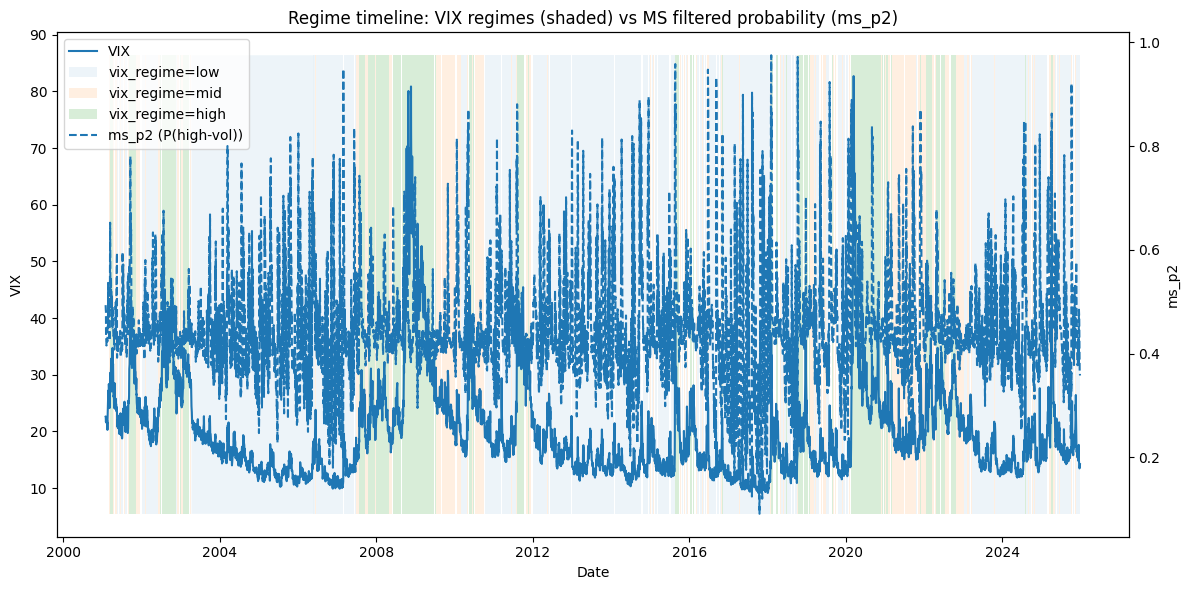

Saved: figures/regime_timeline_vix_ms.png


In [ ]:
# =========================
# Regime timeline: VIX with regime shading + ms_p2
# Requires: df_model has ['VIX','vix_regime','ms_p2']
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "df_model" in globals(), "df_model not found."
need = ["VIX", "vix_regime", "ms_p2"]
for c in need:
    assert c in df_model.columns, f"df_model missing column: {c}"

os.makedirs("figures", exist_ok=True)

tmp = df_model.copy().sort_index()
tmp.index = pd.to_datetime(tmp.index)
tmp = tmp.dropna(subset=["VIX", "vix_regime", "ms_p2"]).copy()

# Map regimes to numeric segments for shading
reg = tmp["vix_regime"].astype(str).to_numpy()
x = tmp.index

fig = plt.figure(figsize=(12, 6))
ax1 = plt.gca()

# Plot VIX
ax1.plot(x, tmp["VIX"].to_numpy(), label="VIX")
ax1.set_ylabel("VIX")
ax1.set_xlabel("Date")

# Shading by regime (low/mid/high)
# We avoid hardcoding many colors; use three alphas with generic fills.
ymin, ymax = ax1.get_ylim()

def shade(mask, alpha, label):
    # fill between ymin/ymax where mask True
    ax1.fill_between(x, ymin, ymax, where=mask, alpha=alpha, label=label, step=None)

mask_low  = (reg == "low")
mask_mid  = (reg == "mid")
mask_high = (reg == "high")

shade(mask_low,  0.08, "vix_regime=low")
shade(mask_mid,  0.12, "vix_regime=mid")
shade(mask_high, 0.18, "vix_regime=high")

# ms_p2 on second axis
ax2 = ax1.twinx()
ax2.plot(x, tmp["ms_p2"].to_numpy(), linestyle="--", label="ms_p2 (P(high-vol))")
ax2.set_ylabel("ms_p2")

# legend merge
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.title("Regime timeline: VIX regimes (shaded) vs MS filtered probability (ms_p2)")
plt.tight_layout()
out = "figures/regime_timeline_vix_ms.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

In [ ]:
# =========================
# MS-GARCH robustness — Stage2-only multi-start
# Purpose: check ordering stability of (P, nu, sigma) under multiple initializations,
#          while saving time by running Stage1 (normal warm start) only once.
# Requires: unpack_params, nll_ms_garch_normal, nll_ms_garch defined; and theta_hat, ms_params.
# =========================


import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os

assert "unpack_params" in globals(), "Need unpack_params() from MS-GARCH cell."
assert "nll_ms_garch_normal" in globals(), "Need nll_ms_garch_normal() from MS-GARCH cell."
assert "nll_ms_garch" in globals(), "Need nll_ms_garch() from MS-GARCH cell."
assert "theta_hat" in globals(),
assert "ms_params" in globals(),

def unc_sigma_from_params(w, a, b):
    """
    Unconditional sigma (in SAME units as r).
    If invalid (w<=0, a<0, b<0, a+b>=1) => NaN.
    """
    if (w <= 0) or (a < 0) or (b < 0) or (a + b >= 0.9999):
        return np.nan
    var = w / (1.0 - a - b)
    if var <= 0:
        return np.nan
    return float(np.sqrt(var))

def label_fix_by_unc_sigma(params_tuple, P):
    """
    Enforce label so state2 is higher-vol based on unconditional sigma.
    """
    (w1,a1,b1,nu1, w2,a2,b2,nu2) = params_tuple
    s1 = unc_sigma_from_params(w1,a1,b1)
    s2 = unc_sigma_from_params(w2,a2,b2)
    if np.isfinite(s1) and np.isfinite(s2) and (s1 > s2):
        # swap states
        (w1,a1,b1,nu1, w2,a2,b2,nu2) = (w2,a2,b2,nu2, w1,a1,b1,nu1)
        # swap transition matrix: P' = S P S
        S = np.array([[0.0, 1.0],
                      [1.0, 0.0]])
        P = S @ P @ S
        s1, s2 = s2, s1
    return (w1,a1,b1,nu1, w2,a2,b2,nu2), P, s1, s2

# -------------------------
# Settings
# -------------------------
N_STARTS = 8
MAXITER_STAGE1 = 160
MAXITER_STAGE2 = 80

# jitter size: smaller than before because we're perturbing already-good warm start
JITTER_SCALE = 0.25
SEED = 2026

# Early stop: if no meaningful improvement after K tries, stop.
EARLY_STOP_PATIENCE = 4
IMPROV_TOL = 1e-4

theta_base = np.array(theta_hat, float)
rng = np.random.default_rng(SEED)

# -------------------------
# Stage 1: run ONCE (normal warm start)
# -------------------------
print("Stage1 (normal) warm start: running once...")
opt1 = minimize(
    nll_ms_garch_normal,
    theta_base,
    method="Powell",
    options={"maxiter": MAXITER_STAGE1, "disp": False}
)
theta_warm_base = opt1.x
base_nll1 = float(opt1.fun)
print(f"Stage1 done. NLL(normal)={base_nll1:.6f}")

# -------------------------
# Stage 2: multi-start on Student-t refine only
# -------------------------
rows = []
best_nll = np.inf
no_improve = 0

for k in range(N_STARTS):
    # perturb warm start
    jitter = rng.normal(0.0, JITTER_SCALE, size=theta_warm_base.shape[0])
    theta0 = theta_warm_base + jitter

    opt2 = minimize(
        nll_ms_garch,
        theta0,
        method="Powell",
        options={"maxiter": MAXITER_STAGE2, "disp": False}
    )

    w1,a1,b1,nu1, w2,a2,b2,nu2, P = unpack_params(opt2.x)
    params, P_fix, s1_unc, s2_unc = label_fix_by_unc_sigma((w1,a1,b1,nu1,w2,a2,b2,nu2), P)
    (w1,a1,b1,nu1, w2,a2,b2,nu2) = params

    p11, p12 = float(P_fix[0,0]), float(P_fix[0,1])
    p21, p22 = float(P_fix[1,0]), float(P_fix[1,1])

    cur_nll = float(opt2.fun)
    improved = (best_nll - cur_nll) > IMPROV_TOL
    if improved:
        best_nll = cur_nll
        no_improve = 0
    else:
        no_improve += 1

    rows.append({
        "start_id": k,
        "success": bool(getattr(opt2, "success", False)),
        "nll": cur_nll,
        "nu1": float(nu1), "nu2": float(nu2),
        "sigma1_unc": float(s1_unc), "sigma2_unc": float(s2_unc),
        "sigma2_gt_sigma1": bool(np.isfinite(s1_unc) and np.isfinite(s2_unc) and (s2_unc > s1_unc)),
        "p11": p11, "p22": p22,
        "p12": p12, "p21": p21,
        "stage1_nll_normal": base_nll1
    })

    print(f"[{k+1}/{N_STARTS}] nll={cur_nll:.6f} | improved={improved} | no_improve={no_improve}")

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stop triggered: no improvement for {EARLY_STOP_PATIENCE} consecutive starts.")
        break

ms_multistart = pd.DataFrame(rows).sort_values("nll").reset_index(drop=True)

# -------------------------
# Summaries
# -------------------------
ok = ms_multistart.copy()
share_order_ok = float(ok["sigma2_gt_sigma1"].mean())
nu_order_ok = float((ok["nu2"] <= ok["nu1"]).mean())  # heuristic: high-vol often has lower nu
print("\n=== MS-GARCH Stage2-only multi-start robustness ===")
print("Runs:", len(ok))
print("Best NLL:", float(ok["nll"].min()), "| Median NLL:", float(ok["nll"].median()))
print("Share with sigma2_unc > sigma1_unc:", share_order_ok)
print("Share with nu2 <= nu1 (fat-tail in state2):", nu_order_ok)
display(ok)

# Compare with single-run ms_params
(w1r,a1r,b1r,nu1r) = ms_params["state1"]
(w2r,a2r,b2r,nu2r) = ms_params["state2"]
P_r = ms_params["P"]
print("\n=== Single-run (current ms_params) ===")
print("nu1, nu2:", float(nu1r), float(nu2r))
print("P:\n", np.array(P_r))
print("unc_sigma1, unc_sigma2:",
      unc_sigma_from_params(float(w1r),float(a1r),float(b1r)),
      unc_sigma_from_params(float(w2r),float(a2r),float(b2r)))

# Save for appendix
os.makedirs("figures", exist_ok=True)
ms_multistart.to_csv("figures/ms_garch_multistart_summary_stage2_only.csv", index=False)
print("\nSaved: figures/ms_garch_multistart_summary_stage2_only.csv")

Stage1 (normal) warm start: running once...
Stage1 done. NLL(normal)=-20430.704339
[1/8] nll=-20478.041835 | improved=True | no_improve=0
[2/8] nll=-20476.616337 | improved=False | no_improve=1
[3/8] nll=-20477.478630 | improved=False | no_improve=2
[4/8] nll=-20477.977726 | improved=False | no_improve=3
[5/8] nll=-20483.261483 | improved=True | no_improve=0
[6/8] nll=-20482.250371 | improved=False | no_improve=1
[7/8] nll=-20477.639219 | improved=False | no_improve=2
[8/8] nll=-20482.988968 | improved=False | no_improve=3

=== MS-GARCH Stage2-only multi-start robustness ===
Runs: 8
Best NLL: -20483.261483038426 | Median NLL: -20478.009780166525
Share with sigma2_unc > sigma1_unc: 1.0
Share with nu2 <= nu1 (fat-tail in state2): 1.0


,start_id,success,nll,nu1,nu2,sigma1_unc,sigma2_unc,sigma2_gt_sigma1,p11,p22,p12,p21,stage1_nll_normal
0,4,True,-20483.261483,13.859978,5.807080,1.125226e-23,0.026095,True,0.926731,0.950803,0.073269,0.049197,-20430.704339
1,7,True,-20482.988968,12.599749,5.584447,1.201701e-23,0.027366,True,0.917047,0.944921,0.082953,0.055079,-20430.704339
2,5,True,-20482.250371,12.603396,5.592982,9.884712e-24,0.026883,True,0.892625,0.927585,0.107375,0.072415,-20430.704339
3,0,True,-20478.041835,8.630864,5.708348,1.131481e-23,0.034935,True,0.920096,0.857643,0.079904,0.142357,-20430.704339
4,3,True,-20477.977726,8.665723,5.697444,9.352411e-24,0.033828,True,0.924934,0.876024,0.075066,0.123976,-20430.704339
5,6,True,-20477.639219,8.461475,6.015556,9.320433e-24,0.034517,True,0.924955,0.858737,0.075045,0.141263,-20430.704339
6,2,True,-20477.478630,8.355561,6.136625,1.131982e-23,0.035470,True,0.925846,0.850880,0.074154,0.149120,-20430.704339
7,1,True,-20476.616337,8.437391,6.572493,1.065938e-23,0.039393,True,0.929224,0.859159,0.070776,0.140841,-20430.704339



=== Single-run (current ms_params) ===
nu1, nu2: 8.04119100904977 6.681477650822954
P:
 [[0.91086488 0.08913512]
 [0.11001724 0.88998276]]
unc_sigma1, unc_sigma2: 1.044711484724416e-23 0.03171098042165698

Saved: figures/ms_garch_multistart_summary_stage2_only.csv


In [ ]:
# GARCH σ_t

r = (df_model["ret"] * 100).astype(float)
am = arch_model(r, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
res_full = am.fit(disp="off")

df_model["sigma_garch"] = res_full.conditional_volatility / 100.0
print(res_full.summary())
print(df_model[["ret","sigma_garch","VIX","vix_regime","policy_regime"]].head())


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                          ret   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8389.10
Distribution:      Standardized Student's t   AIC:                           16786.2
Method:                  Maximum Likelihood   BIC:                           16813.2
                                              No. Observations:                 6268
Date:                      Mon, Feb 23 2026   Df Residuals:                     6268
Time:                              03:55:18   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

In [ ]:
# Mean regression with regime interaction (HAC)
df_mean = df_model.copy()
df_mean["ret_fwd1"] = df_mean["ret"].shift(-1)

df_mean["D_high"] = (df_mean["vix_regime"]=="high").astype(int)
df_mean["D_mid"]  = (df_mean["vix_regime"]=="mid").astype(int)

df_mean["risk"] = df_mean["sigma_garch"]
df_mean = df_mean.dropna(subset=["ret_fwd1","risk","D_high","D_mid"]).copy()

X = pd.DataFrame({
    "const": 1.0,
    "risk": df_mean["risk"],
    "D_high": df_mean["D_high"],
    "D_mid": df_mean["D_mid"],
    "risk_x_high": df_mean["risk"] * df_mean["D_high"],
    "risk_x_mid":  df_mean["risk"] * df_mean["D_mid"],
})
y = df_mean["ret_fwd1"]

ols = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:               ret_fwd1   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4303
Date:                Mon, 23 Feb 2026   Prob (F-statistic):              0.828
Time:                        03:55:18   Log-Likelihood:                 18784.
No. Observations:                6267   AIC:                        -3.756e+04
Df Residuals:                    6261   BIC:                        -3.751e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -8.582e-08      0.000     -0.000      

In [ ]:
# Tail risk structure（regime-dependent）

import numpy as np
import pandas as pd

df_tail = df_model.copy().sort_index()
df_tail.index = pd.to_datetime(df_tail.index)

# -------------------------
# Join OOS sigma_pred from roll (SAFE join; no column overlap)
# -------------------------
if "roll" in globals() and hasattr(roll, "columns"):

    candidate_cols = [c for c in ["sigma_pred", "sigma_pred_oos", "sigma_oos", "sigma_hat", "sigma_forecast"] if c in roll.columns]

    if len(candidate_cols) > 0:
        col = candidate_cols[0]
        sig = roll[[col]].copy()
        sig.index = pd.to_datetime(sig.index)
        sig = sig.rename(columns={col: "sigma_pred_oos"})


        if "sigma_pred_oos" in df_tail.columns:
            df_tail = df_tail.drop(columns=["sigma_pred_oos"])

        df_tail = df_tail.join(sig, how="left")
    else:
        df_tail["sigma_pred_oos"] = np.nan
else:
    df_tail["sigma_pred_oos"] = np.nan

# -------------------------
# DEBUG
# -------------------------
print("\n=== DEBUG: roll availability / structure ===")
print("'roll' in globals():", "roll" in globals())

if "roll" in globals():
    print("type(roll):", type(roll))
    if hasattr(roll, "columns"):
        print("roll columns (first 30):", list(roll.columns)[:30])
        try:
            print("roll index type/dtype:", type(roll.index), getattr(roll.index, "dtype", None))
            print("roll date min/max:", roll.index.min(), roll.index.max())
        except Exception as e:
            print("roll index min/max check failed:", repr(e))
        print("roll head():")
        display(roll.head(5))
    else:
        print("roll has no .columns; dir sample:", [x for x in dir(roll) if "sigma" in x.lower() or "pred" in x.lower()][:30])

print("\n=== DEBUG: df_tail sigma_pred_oos after join ===")
print("df_tail sigma_pred_oos NaN%:", df_tail["sigma_pred_oos"].isna().mean())
print("df_tail date min/max:", df_tail.index.min(), df_tail.index.max())
print("sigma_pred_oos non-NaN count:", df_tail["sigma_pred_oos"].notna().sum())
print("sample non-NaN rows (if any):")
display(df_tail.loc[df_tail["sigma_pred_oos"].notna(), ["sigma_pred_oos"]].head(10))

# -------------------------
# In-sample z (reference) + OOS/used z (preferred; fallback to sigma_garch)
# -------------------------
ret = pd.to_numeric(df_tail["ret"], errors="coerce")
sig_g = pd.to_numeric(df_tail["sigma_garch"], errors="coerce")
sig_o = pd.to_numeric(df_tail["sigma_pred_oos"], errors="coerce")

df_tail["z_in"] = ret / (sig_g + 1e-12)

sigma_used = sig_o.where(sig_o.notna(), sig_g)   # preferred OOS, fallback to in-sample
df_tail["sigma_used"] = sigma_used
df_tail["z_used"] = ret / (sigma_used + 1e-12)

# -------------------------
# Tail indicators: reference (z_in), OOS/used z (MAIN)
# -------------------------
for k in [2, 3]:
    df_tail[f"I_zin_lt_-{k}"]   = (df_tail["z_in"]   < -k).astype(int)
    df_tail[f"I_zoos_lt_-{k}"]  = (df_tail["z_used"] < -k).astype(int)  # alias name kept
    df_tail[f"I_z_lt_-{k}"]     = (df_tail["z_used"] < -k).astype(int)  # MAIN

def tail_desc(g):
    x = pd.to_numeric(g["ret"], errors="coerce").dropna()
    return pd.Series({
        "n": int(len(x)),
        "mean_ret": float(x.mean()) if len(x) else np.nan,
        "std_ret": float(x.std()) if len(x) else np.nan,
        "skew_ret": float(x.skew()) if len(x) else np.nan,
        "kurt_ret": float(x.kurtosis()) if len(x) else np.nan,

        # in-sample standardized tail (reference)
        "P(z_in<-2)": float(g["I_zin_lt_-2"].mean()),
        "P(z_in<-3)": float(g["I_zin_lt_-3"].mean()),

        # MAIN tail (preferred, OOS sigma when available)
        "P(z_used<-2)": float(g["I_z_lt_-2"].mean()),
        "P(z_used<-3)": float(g["I_z_lt_-3"].mean()),

        "mean_sigma_garch": float(pd.to_numeric(g["sigma_garch"], errors="coerce").mean()),
        "mean_sigma_pred_oos": float(pd.to_numeric(g["sigma_pred_oos"], errors="coerce").mean()),
        "NaN%_sigma_pred_oos": float(pd.to_numeric(g["sigma_pred_oos"], errors="coerce").isna().mean()),
        "mean_VIX": float(pd.to_numeric(g["VIX"], errors="coerce").mean()) if "VIX" in g.columns else np.nan,
    })

print("=== Tail structure by VIX regime (z_in reference vs z_used preferred) ===")
display(df_tail.groupby("vix_regime").apply(tail_desc).sort_index())

if "policy_regime" in df_tail.columns:
    print("=== Tail structure by policy regime (z_in reference vs z_used preferred) ===")
    display(df_tail.groupby("policy_regime").apply(tail_desc).sort_index())

# -------------------------
# Tail structure by endogenous MS state (risk-scaled by state sigma) + also show z_used
# -------------------------
assert "ms_state" in df_tail.columns, "df_tail missing ms_state. Ensure MS-GARCH cell ran."
assert "ms_sigma1" in df_tail.columns and "ms_sigma2" in df_tail.columns, "Missing ms_sigma1/ms_sigma2."

sig1 = pd.to_numeric(df_tail["ms_sigma1"], errors="coerce").to_numpy()
sig2 = pd.to_numeric(df_tail["ms_sigma2"], errors="coerce").to_numpy()
state = pd.to_numeric(df_tail["ms_state"], errors="coerce").fillna(0).astype(int).to_numpy()

sig_state = np.where(state == 0, sig1, sig2)
df_tail["z_ms"] = ret.to_numpy() / (sig_state + 1e-12)
df_tail["I_zms_lt_-2"] = (df_tail["z_ms"] < -2).astype(int)
df_tail["I_zms_lt_-3"] = (df_tail["z_ms"] < -3).astype(int)

def tail_desc_ms(g):
    x = pd.to_numeric(g["ret"], errors="coerce").dropna()
    return pd.Series({
        "n": int(len(x)),
        "std_ret": float(x.std()) if len(x) else np.nan,
        "P(z_ms<-2)": float(g["I_zms_lt_-2"].mean()),
        "P(z_ms<-3)": float(g["I_zms_lt_-3"].mean()),
        "avg_sigma_state": float(np.mean(np.where(g["ms_state"]==0, g["ms_sigma1"], g["ms_sigma2"]))),
        "avg_p_state2": float(g["ms_p2"].mean()) if "ms_p2" in g.columns else np.nan,

        # robustness tail on preferred z_used, grouped by ms_state
        "P(z_used<-3)": float(g["I_z_lt_-3"].mean()),
    })

print("\n=== Tail structure by MS-GARCH endogenous state ===")
display(df_tail.groupby("ms_state").apply(tail_desc_ms).sort_index())

if "ms_p2" in df_tail.columns:
    tmp = df_tail.copy()
    tmp["ms_p2_bin"] = pd.qcut(tmp["ms_p2"], q=4, labels=["Q1(low)", "Q2", "Q3", "Q4(high)"])
    print("\n=== Tail structure by ms_p2 quartiles ===")
    display(tmp.groupby("ms_p2_bin").apply(tail_desc).sort_index())


=== DEBUG: roll availability / structure ===
'roll' in globals(): True
type(roll): <class 'pandas.core.frame.DataFrame'>
roll columns (first 30): ['sigma_pred', 'nu_pred', 'sigma_true', 'abs_ret', 'VIX', 'vix_regime', 'policy_regime', 'ms_state', 'ms_p2', 'err_absret', 'err_ratio']
roll index type/dtype: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns]
roll date min/max: 2006-02-03 00:00:00 2025-12-30 00:00:00
roll head():


,sigma_pred,nu_pred,sigma_true,abs_ret,VIX,vix_regime,policy_regime,ms_state,ms_p2,err_absret,err_ratio
date,,,,,,,,,,,
2006-02-03,0.007353,24.450382,0.008092,0.004977,12.96,low,hold,1,0.505675,-0.002376,0.676910
2006-02-06,0.007237,24.621081,0.007852,0.002611,13.04,low,hold,0,0.437067,-0.004627,0.360705
2006-02-07,0.007051,24.477280,0.007491,0.008886,13.59,low,hold,0,0.485801,0.001835,1.260239
2006-02-08,0.007203,25.020389,0.007757,0.009044,12.83,low,hold,1,0.523651,0.001841,1.255650
2006-02-09,0.007353,25.536590,0.008003,0.001660,13.12,low,hold,0,0.445950,-0.005693,0.225761



=== DEBUG: df_tail sigma_pred_oos after join ===
df_tail sigma_pred_oos NaN%: 0.20105313547151749
df_tail date min/max: 2001-01-29 00:00:00 2025-12-29 00:00:00
sigma_pred_oos non-NaN count: 5007
sample non-NaN rows (if any):


,sigma_pred_oos
2006-02-03,0.007353
2006-02-06,0.007237
2006-02-07,0.007051
2006-02-08,0.007203
2006-02-09,0.007353
2006-02-10,0.007164
2006-02-13,0.006967
2006-02-14,0.006782
2006-02-15,0.007097
2006-02-16,0.006952


=== Tail structure by VIX regime (z_in reference vs z_used preferred) ===


...

/tmp/ipython-input-3528549039.py:148: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_tail.groupby("ms_state").apply(tail_desc_ms).sort_index())


,n,std_ret,P(z_ms<-2),P(z_ms<-3),avg_sigma_state,avg_p_state2,P(z_used<-3)
ms_state,,,,,,,
0,4942.0,0.009920,0.012748,0.000202,0.009685,0.404821,0.000405
1,1325.0,0.017965,0.080000,0.016604,0.013259,0.602844,0.033962



=== Tail structure by ms_p2 quartiles ===


/tmp/ipython-input-3528549039.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(tmp.groupby("ms_p2_bin").apply(tail_desc).sort_index())
/tmp/ipython-input-3528549039.py:154: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(tmp.groupby("ms_p2_bin").apply(tail_desc).sort_index())


,n,mean_ret,std_ret,skew_ret,kurt_ret,P(z_in<-2),P(z_in<-3),P(z_used<-2),P(z_used<-3),mean_sigma_garch,mean_sigma_pred_oos,NaN%_sigma_pred_oos,mean_VIX
ms_p2_bin,,,,,,,,,,,,,
Q1(low),1567.0,0.000204,0.006968,-2.415550,34.811420,0.007658,0.000638,0.007020,0.000638,0.007224,0.007328,0.164008,15.036828
Q2,1567.0,0.000853,0.010403,-0.010854,9.065489,0.008296,0.000000,0.007658,0.000638,0.011110,0.011232,0.222080,21.017824
Q3,1566.0,0.000639,0.011237,0.378420,7.160891,0.016603,0.000000,0.018519,0.000000,0.011976,0.011734,0.239464,21.535402
Q4(high),1567.0,-0.000372,0.017333,-0.205263,7.191794,0.098915,0.029355,0.096362,0.028717,0.011949,0.011976,0.178685,21.147084


In [ ]:
import numpy as np
import pandas as pd


df_check = df_tail.copy()

print("Columns available:", [c for c in ["ret", "sigma_garch", "sigma_pred_oos", "z_in", "z_used"] if c in df_check.columns])


if "sigma_pred_oos" not in df_check.columns:
    print("\n[FAIL] sigma_pred_oos column not found in df_tail (or df_check).")
else:
    s_oos = df_check["sigma_pred_oos"]
    s_in  = df_check["sigma_garch"] if "sigma_garch" in df_check.columns else None


    nan_rate = s_oos.isna().mean()
    print(f"\nNaN rate of sigma_pred_oos: {nan_rate:.2%}")
    print("sigma_pred_oos describe():")
    print(s_oos.describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))


    if s_in is not None:
        common = df_check[["sigma_pred_oos", "sigma_garch"]].dropna()
        print(f"\nCommon non-NaN rows for sigma comparison: {len(common):,}")
        if len(common) > 0:
            diff = common["sigma_pred_oos"] - common["sigma_garch"]
            rel  = diff / common["sigma_garch"].replace(0, np.nan)
            print("\nDiff (oos - in) describe():")
            print(diff.describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))
            print("\nRelative diff (oos-in)/in describe():")
            print(rel.describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))
            print("\nCorrelation(sigma_pred_oos, sigma_garch):", common["sigma_pred_oos"].corr(common["sigma_garch"]))

Columns available: ['ret', 'sigma_garch', 'sigma_pred_oos', 'z_in', 'z_used']

NaN rate of sigma_pred_oos: 20.11%
sigma_pred_oos describe():
count    5007.000000
mean        0.010521
std         0.006721
min         0.004100
1%          0.004662
5%          0.005257
10%         0.005732
50%         0.008667
90%         0.016763
95%         0.021673
99%         0.045226
max         0.080894
Name: sigma_pred_oos, dtype: float64

Common non-NaN rows for sigma comparison: 5,007

Diff (oos - in) describe():
count    5007.000000
mean        0.000006
std         0.001028
min        -0.007927
1%         -0.003258
5%         -0.001517
10%        -0.000982
50%         0.000100
90%         0.000781
95%         0.001142
99%         0.002867
max         0.014381
dtype: float64

Relative diff (oos-in)/in describe():
count    5007.000000
mean        0.003186
std         0.073369
min        -0.285414
1%         -0.189397
5%         -0.133075
10%        -0.097038
50%         0.011379
90%         0.0886

In [ ]:
# ======  z_used vs z_in  ======
need_cols = ["z_in", "z_used"]
missing = [c for c in need_cols if c not in df_check.columns]
if missing:
    print("\n[FAIL] Missing columns:", missing)
else:
    comp = df_check[["z_in", "z_used"]].dropna()
    print(f"\nRows with both z_in and z_used non-NaN: {len(comp):,}")

    if len(comp) == 0:
        print("[FAIL] No comparable rows.")
    else:

        max_abs = (comp["z_used"] - comp["z_in"]).abs().max()

        eq_rate = np.isclose(comp["z_used"], comp["z_in"], rtol=1e-12, atol=1e-12).mean()

        d = comp["z_used"] - comp["z_in"]

        print(f"Max |z_used - z_in|: {max_abs:.6g}")
        print(f"Share of rows where z_used ≈ z_in: {eq_rate:.2%}")
        print("\n(z_used - z_in) describe():")
        print(d.describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))

        if "sigma_pred_oos" in df_check.columns and "sigma_garch" in df_check.columns:
            scomp = df_check[["sigma_pred_oos", "sigma_garch"]].dropna()
            if len(scomp) > 0:
                sig_eq = np.isclose(scomp["sigma_pred_oos"], scomp["sigma_garch"], rtol=1e-12, atol=1e-12).mean()
                print(f"\nShare where sigma_pred_oos ≈ sigma_garch (on non-NaN overlap): {sig_eq:.2%}")


Rows with both z_in and z_used non-NaN: 6,267
Max |z_used - z_in|: 0.621995
Share of rows where z_used ≈ z_in: 20.31%

(z_used - z_in) describe():
count    6267.000000
mean        0.000073
std         0.068243
min        -0.621995
1%         -0.212633
5%         -0.096833
10%        -0.054846
50%         0.000000
90%         0.054642
95%         0.099723
99%         0.235380
max         0.505388
dtype: float64

Share where sigma_pred_oos ≈ sigma_garch (on non-NaN overlap): 0.00%


In [ ]:
cols_show = [c for c in ["ret", "sigma_garch", "sigma_pred_oos", "z_in", "z_used"] if c in df_check.columns]
print("\nSample rows where sigma_pred_oos is NaN (if any):")
if "sigma_pred_oos" in df_check.columns:
    display(df_check.loc[df_check["sigma_pred_oos"].isna(), cols_show].head(10))

print("\nSample rows where z_used differs from z_in (if any):")
diff_mask = False
if all(c in df_check.columns for c in ["z_in", "z_used"]):
    diff_mask = ~np.isclose(df_check["z_used"], df_check["z_in"], rtol=1e-12, atol=1e-12)
    display(df_check.loc[diff_mask, cols_show].head(10))


Sample rows where sigma_pred_oos is NaN (if any):


,ret,sigma_garch,sigma_pred_oos,z_in,z_used
2001-01-29,0.005322,0.013722,NaN,0.387813,0.387813
2001-01-30,0.008746,0.012999,NaN,0.672842,0.672842
2001-01-31,-0.005676,0.012573,NaN,-0.451452,-0.451452
2001-02-01,0.006619,0.011965,NaN,0.553246,0.553246
2001-02-02,-0.022954,0.011471,NaN,-2.001011,-2.001011
2001-02-05,0.007317,0.013451,NaN,0.543964,0.543964
2001-02-06,-0.002950,0.012871,NaN,-0.229169,-0.229169
2001-02-07,-0.005184,0.012119,NaN,-0.427749,-0.427749
2001-02-08,-0.011725,0.011521,NaN,-1.017686,-1.017686
2001-02-09,-0.009662,0.011578,NaN,-0.834522,-0.834522



Sample rows where z_used differs from z_in (if any):


,ret,sigma_garch,sigma_pred_oos,z_in,z_used
2006-02-03,-0.004977,0.008092,0.007353,-0.615100,-0.676910
2006-02-06,0.002611,0.007852,0.007237,0.332473,0.360705
2006-02-07,-0.008886,0.007491,0.007051,-1.186207,-1.260239
2006-02-08,0.009044,0.007757,0.007203,1.165859,1.255650
2006-02-09,-0.001660,0.008003,0.007353,-0.207419,-0.225761
2006-02-10,0.001818,0.007597,0.007164,0.239286,0.253734
2006-02-13,-0.001818,0.007229,0.006967,-0.251465,-0.260909
2006-02-14,0.010545,0.006893,0.006782,1.529871,1.554698
2006-02-15,0.003516,0.007526,0.007097,0.467219,0.495505
2006-02-16,0.007460,0.007242,0.006952,1.030202,1.073184


In [ ]:
# =========================
# POT-GPD tail index xi
# Output: by vix_regime (external proxy) AND by ms_p2_bin (endogenous, balanced)
# Also keep ms_state as a supplementary split
#
# NOTE:
# loss = -ret > 0, so TAIL_Q=0.95 means "top 5% losses" (right tail of loss distribution)
# =========================
import numpy as np
import pandas as pd
from scipy.stats import genpareto
from IPython.display import display

df_evt = df_model.copy().sort_index()
df_evt["loss"] = -df_evt["ret"]  # positive loss

# Ensure regime columns exist
need = ["loss", "vix_regime", "ms_state", "ms_p2_bin"]
for c in need:
    if c not in df_evt.columns:
        raise KeyError(f"df_model missing '{c}'. Ensure MS-GARCH cell created ms_state & ms_p2_bin.")

df_evt = df_evt.dropna(subset=need).copy()

TAIL_Q = 0.95          # TOP 5% LOSSES (since loss = -ret > 0)
MIN_TAIL = 30
MIN_TOTAL = 300        # avoid unstable xi from too-few obs
EPS = 1e-12

def fit_gpd_xi(x, tail_q=0.95, min_tail=30, min_total=300):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x[x > 0]

    if len(x) < min_total:
        return {"u": np.nan, "tail_n": 0, "xi": np.nan, "mean_exceed": np.nan, "status": "too few total obs"}

    u = float(np.quantile(x, tail_q))
    # If threshold is ~0, the "tail" is not really a tail in losses -> unstable fit
    if not np.isfinite(u) or u <= EPS:
        return {"u": u, "tail_n": 0, "xi": np.nan, "mean_exceed": np.nan, "status": "u too small / invalid"}

    tail = x[x > u]
    n_tail = int(len(tail))
    if n_tail < min_tail:
        return {"u": u, "tail_n": n_tail, "xi": np.nan, "mean_exceed": np.nan, "status": f"tail<{min_tail}"}

    y = tail - u
    # guard against pathological case: all exceedances nearly zero
    if np.nanmax(y) <= EPS:
        return {"u": u, "tail_n": n_tail, "xi": np.nan, "mean_exceed": float(np.nanmean(y)), "status": "exceedances ~0"}

    try:
        c, loc, scale = genpareto.fit(y, floc=0)  # xi=c
        return {
            "u": u,
            "tail_n": n_tail,
            "xi": float(c),
            "mean_exceed": float(np.nanmean(y)),
            "status": "ok",
        }
    except Exception as e:
        return {"u": u, "tail_n": n_tail, "xi": np.nan, "mean_exceed": float(np.nanmean(y)),
                "status": f"fit_fail:{type(e).__name__}"}

rows = []

# --- 1) by VIX regime (benchmark) ---
for reg, g in df_evt.groupby("vix_regime"):
    out = fit_gpd_xi(g["loss"].values, tail_q=TAIL_Q, min_tail=MIN_TAIL, min_total=MIN_TOTAL)
    out.update({"group": "vix_regime", "key": str(reg), "n": int(len(g))})
    rows.append(out)

# --- 2) by ms_p2_bin (mainline endogenous regime summary, balanced) ---
for b, g in df_evt.groupby("ms_p2_bin"):
    out = fit_gpd_xi(g["loss"].values, tail_q=TAIL_Q, min_tail=MIN_TAIL, min_total=MIN_TOTAL)
    out.update({"group": "ms_p2_bin", "key": str(b), "n": int(len(g))})
    rows.append(out)

# --- 3) by ms_state (supplementary; may be imbalanced depending on fit) ---
for s, g in df_evt.groupby("ms_state"):
    out = fit_gpd_xi(g["loss"].values, tail_q=TAIL_Q, min_tail=MIN_TAIL, min_total=MIN_TOTAL)
    out.update({"group": "ms_state", "key": str(int(s)), "n": int(len(g))})
    rows.append(out)

xi_tbl = pd.DataFrame(rows).set_index(["group", "key"]).sort_index()

print("=== POT-GPD xi (tail index) by vix_regime vs ms_p2_bin (mainline) + ms_state (supplement) ===")
display(xi_tbl)

print("\nInterpretation:")
print("- xi > 0 : heavy tail (power-law like)")
print("- xi ~ 0 : exponential-like tail")
print("- xi < 0 : bounded tail")
print("- mean_exceed helps describe tail shift magnitude above threshold u")

/tmp/ipython-input-2265242920.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, g in df_evt.groupby("ms_p2_bin"):


=== POT-GPD xi (tail index) by vix_regime vs ms_p2_bin (mainline) + ms_state (supplement) ===


u  tail_n        xi  mean_exceed status     n
group      key                                                           
ms_p2_bin  Q1(low)   0.007585      35 -0.332271     0.021644     ok  1567
           Q2        0.020714      35  0.383777     0.008410     ok  1567
           Q3        0.022693      36 -0.132260     0.007688     ok  1567
           Q4(high)  0.035667      37  0.173348     0.017361     ok  1567
ms_state   0         0.021580     110  0.242345     0.009743     ok  4943
           1         0.036911      32  0.187664     0.017974     ok  1325
vix_regime high      0.043437      38  0.414209     0.015405     ok  1420
           low       0.014118      72 -0.321053     0.003466     ok  3528
           mid       0.020676      33 -0.035284     0.004433     ok  1320


Interpretation:
- xi > 0 : heavy tail (power-law like)
- xi ~ 0 : exponential-like tail
- xi < 0 : bounded tail
- mean_exceed helps describe tail shift magnitude above threshold u


=== xi bootstrap CI by vix_regime ===


,xi_hat,ci_low,ci_high,n,n_exc
vix_regime,,,,,
high,0.622126,0.508538,0.829256,1420,71
low,NaN,NaN,NaN,3528,177
mid,NaN,0.502543,0.673164,1320,66


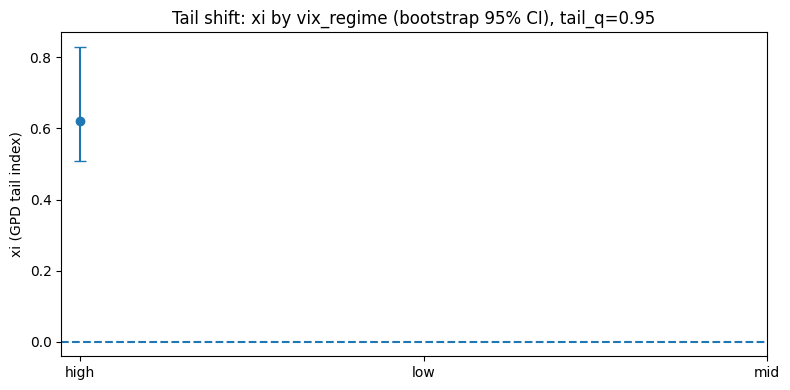

Saved: figures/tail_xi_ci_by_vix_regime.png


/tmp/ipython-input-1879716082.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for k, g in df_evt.dropna(subset=[group_col, "loss"]).groupby(group_col):



=== xi bootstrap CI by ms_p2_bin ===


,xi_hat,ci_low,ci_high,n,n_exc
ms_p2_bin,,,,,
Q1(low),1.105983,0.730619,1.607577,1567,79
Q2,0.958724,0.522261,1.474977,1567,79
Q3,NaN,0.501870,0.685810,1567,79
Q4(high),0.772418,0.532197,1.034875,1567,79


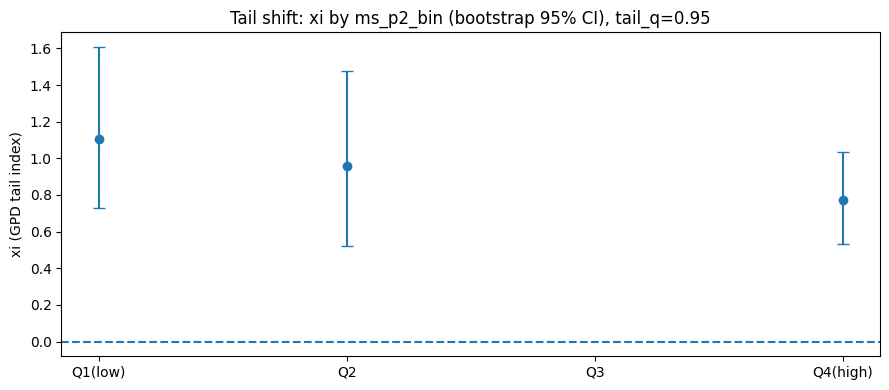

Saved: figures/tail_xi_ci_by_ms_p2_bin.png


In [ ]:
# =========================
# Tail shift plot: xi with bootstrap CI by vix_regime (and optional ms_p2_bin)
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "df_evt" in globals(),
assert "loss" in df_evt.columns and "vix_regime" in df_evt.columns, "df_evt missing loss/vix_regime."

os.makedirs("figures", exist_ok=True)

TAIL_Q = globals().get("TAIL_Q", 0.95)
B = 2000
SEED = 42
rng = np.random.default_rng(SEED)

def gpd_xi_mom(exceed):
    exceed = np.asarray(exceed, float)
    exceed = exceed[np.isfinite(exceed)]
    if len(exceed) < 10:
        return np.nan
    m1 = exceed.mean()
    m2 = (exceed**2).mean()
    if (m2 <= 2*m1*m1) or (m1 <= 0):
        return np.nan
    # method-of-moments for GPD
    xi = 0.5 * (m2 / (m1*m1) - 1.0)
    return float(xi)

def boot_ci_xi(loss, tail_q=0.95, B=2000):
    loss = np.asarray(loss, float)
    loss = loss[np.isfinite(loss)]
    if len(loss) < 300:
        return {"xi_hat": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": len(loss), "n_exc": 0}
    u = np.quantile(loss, tail_q)
    exc = loss[loss > u] - u
    if len(exc) < 30:
        return {"xi_hat": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": len(loss), "n_exc": len(exc)}
    xi_hat = gpd_xi_mom(exc)
    boots = []
    for _ in range(B):
        samp = rng.choice(exc, size=len(exc), replace=True)
        boots.append(gpd_xi_mom(samp))
    boots = np.asarray([b for b in boots if np.isfinite(b)], float)
    if len(boots) < 100:
        return {"xi_hat": xi_hat, "ci_low": np.nan, "ci_high": np.nan, "n": len(loss), "n_exc": len(exc)}
    return {
        "xi_hat": float(xi_hat),
        "ci_low": float(np.quantile(boots, 0.025)),
        "ci_high": float(np.quantile(boots, 0.975)),
        "n": int(len(loss)),
        "n_exc": int(len(exc)),
    }

def make_xi_ci_table(group_col):
    out = []
    for k, g in df_evt.dropna(subset=[group_col, "loss"]).groupby(group_col):
        res = boot_ci_xi(g["loss"].values, tail_q=TAIL_Q, B=B)
        res[group_col] = str(k)
        out.append(res)
    tab = pd.DataFrame(out).set_index(group_col).sort_index()
    return tab

xi_ci_vix = make_xi_ci_table("vix_regime")
print("=== xi bootstrap CI by vix_regime ===")
display(xi_ci_vix)

# Plot
labels = xi_ci_vix.index.tolist()
x = np.arange(len(labels))
y = xi_ci_vix["xi_hat"].to_numpy()
yerr_low = y - xi_ci_vix["ci_low"].to_numpy()
yerr_high = xi_ci_vix["ci_high"].to_numpy() - y

fig = plt.figure(figsize=(8, 4))
ax = plt.gca()
ax.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=4)
ax.axhline(0.0, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("xi (GPD tail index)")
ax.set_title(f"Tail shift: xi by vix_regime (bootstrap 95% CI), tail_q={TAIL_Q}")
plt.tight_layout()
out = "figures/tail_xi_ci_by_vix_regime.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# Optional: ms_p2_bin quartiles
if "ms_p2_bin" in df_evt.columns:
    xi_ci_msbin = make_xi_ci_table("ms_p2_bin")
    print("\n=== xi bootstrap CI by ms_p2_bin ===")
    display(xi_ci_msbin)

    labels = xi_ci_msbin.index.tolist()
    x = np.arange(len(labels))
    y = xi_ci_msbin["xi_hat"].to_numpy()
    yerr_low = y - xi_ci_msbin["ci_low"].to_numpy()
    yerr_high = xi_ci_msbin["ci_high"].to_numpy() - y

    fig = plt.figure(figsize=(9, 4))
    ax = plt.gca()
    ax.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=4)
    ax.axhline(0.0, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel("xi (GPD tail index)")
    ax.set_title(f"Tail shift: xi by ms_p2_bin (bootstrap 95% CI), tail_q={TAIL_Q}")
    plt.tight_layout()
    out = "figures/tail_xi_ci_by_ms_p2_bin.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

In [ ]:
# =========================
# Bootstrap test for tail index difference (xi_high - xi_low)
# H0: xi_high = xi_low
# =========================
import numpy as np
import pandas as pd

# ---- CONFIG ----
RET_COL = "ret"
REG_COL = "vix_regime"
B = 2000
SEED = 42

# EVT settings
tail_q = 0.95
min_tail = 30
eps = 1e-12

# ---- helper: fit xi by PWM-like moment estimator for GPD exceedances ----
# exceedances y = loss - u, conditional on loss > u
# shape xi estimated via method-of-moments (fast & stable for bootstrap)
def gpd_xi_mom(exceed):
    exceed = np.asarray(exceed, float)
    exceed = exceed[np.isfinite(exceed)]
    if len(exceed) < 5:
        return np.nan
    m1 = exceed.mean()
    m2 = (exceed**2).mean()
    # Var = m2 - m1^2
    var = m2 - m1**2
    if not np.isfinite(var) or var <= 0:
        return np.nan
    # GPD MOM: xi = 0.5 * (1 - m1^2 / var)
    xi = 0.5 * (1.0 - (m1**2) / (var + eps))
    return xi

def fit_xi_for_regime(df_reg, tail_q=0.95):
    # left tail => define loss = -ret
    r = pd.to_numeric(df_reg[RET_COL], errors="coerce").dropna().values
    if len(r) < 200:
        return np.nan, {"status": "too_few_obs", "tail_n": 0, "u": np.nan}
    loss = -r
    u = np.quantile(loss, tail_q)
    exceed = loss[loss > u] - u
    tail_n = len(exceed)
    if tail_n < min_tail:
        return np.nan, {"status": f"tail<{min_tail}", "tail_n": tail_n, "u": u}
    xi = gpd_xi_mom(exceed)
    if not np.isfinite(xi):
        return np.nan, {"status": "xi_nan", "tail_n": tail_n, "u": u}
    return float(xi), {"status": "ok", "tail_n": tail_n, "u": u}

# ---- 0) sanity: check columns ----
assert REG_COL in df_tail.columns, f"df_tail missing {REG_COL}"
assert RET_COL in df_tail.columns, f"df_tail missing {RET_COL}"

df_use = df_tail[[RET_COL, REG_COL]].dropna().copy()
df_high = df_use[df_use[REG_COL] == "high"]
df_low  = df_use[df_use[REG_COL] == "low"]

print("n_high:", len(df_high), "n_low:", len(df_low))
xi_h, info_h = fit_xi_for_regime(df_high, tail_q=tail_q)
xi_l, info_l = fit_xi_for_regime(df_low,  tail_q=tail_q)
print("Point estimate xi_high:", xi_h, "|", info_h)
print("Point estimate xi_low :", xi_l, "|", info_l)

if (not np.isfinite(xi_h)) or (not np.isfinite(xi_l)):
    raise ValueError("Point xi estimate failed (likely tail too small or bad data). "
                     "Check RET_COL name and min_tail / tail_q settings.")

delta_hat = xi_h - xi_l
print("Point delta (xi_high - xi_low):", delta_hat)

# ---- 1) bootstrap resample within each regime ----
rng = np.random.default_rng(SEED)
high_vals = df_high[RET_COL].astype(float).values
low_vals  = df_low[RET_COL].astype(float).values

boot_delta = np.empty(B, dtype=float)
boot_xih   = np.empty(B, dtype=float)
boot_xil   = np.empty(B, dtype=float)

fail = 0
for b in range(B):
    samp_h = rng.choice(high_vals, size=len(high_vals), replace=True)
    samp_l = rng.choice(low_vals,  size=len(low_vals),  replace=True)

    tmp_h = pd.DataFrame({RET_COL: samp_h})
    tmp_l = pd.DataFrame({RET_COL: samp_l})

    xih_b, infohb = fit_xi_for_regime(tmp_h, tail_q=tail_q)
    xil_b, infolb = fit_xi_for_regime(tmp_l, tail_q=tail_q)

    if (not np.isfinite(xih_b)) or (not np.isfinite(xil_b)):
        boot_delta[b] = np.nan
        boot_xih[b] = np.nan
        boot_xil[b] = np.nan
        fail += 1
        continue

    boot_xih[b] = xih_b
    boot_xil[b] = xil_b
    boot_delta[b] = xih_b - xil_b

boot_delta = boot_delta[np.isfinite(boot_delta)]
boot_xih   = boot_xih[np.isfinite(boot_xih)]
boot_xil   = boot_xil[np.isfinite(boot_xil)]

print(f"\nBootstrap reps requested: {B} | valid deltas: {len(boot_delta)} | failed: {fail}")

# ---- 2) 95% CI + two-sided bootstrap p-value (percentile method) ----
ci_lo, ci_hi = np.quantile(boot_delta, [0.025, 0.975])

# two-sided p-value via "how often delta crosses 0" (simple bootstrap)
p_two = 2.0 * min(np.mean(boot_delta <= 0), np.mean(boot_delta >= 0))
p_two = min(p_two, 1.0)

print("\n=== Bootstrap test: delta = xi_high - xi_low ===")
print("delta_hat:", delta_hat)
print("95% CI:", (ci_lo, ci_hi))
print("bootstrap p-value (two-sided):", p_two)

if (ci_lo > 0) or (ci_hi < 0):
    print("\n✅ Conclusion: Reject H0 at 5% — Tail index differs across regimes.")
    print("   Tail index differs significantly across volatility regimes.")
else:
    print("\n⚠️ Conclusion: Fail to reject H0 at 5% — evidence not strong enough (with current settings).")

# ---- compact table for write-up ----
out = pd.DataFrame({
    "xi_hat": [xi_h, xi_l],
    "tail_n": [info_h["tail_n"], info_l["tail_n"]],
    "threshold_u": [info_h["u"], info_l["u"]],
}, index=["high", "low"])
print("\nPoint estimates table:")
display(out)

sum_tbl = pd.DataFrame({
    "delta_hat": [delta_hat],
    "ci_2.5%": [ci_lo],
    "ci_97.5%": [ci_hi],
    "p_boot_2sided": [p_two],
    "B_valid": [len(boot_delta)],
    "B_fail": [fail],
})
display(sum_tbl)


n_high: 1420 n_low: 3528
Point estimate xi_high: 0.09815210593201945 | {'status': 'ok', 'tail_n': 71, 'u': np.float64(0.03293618784461825)}
Point estimate xi_low : -0.1562576279792477 | {'status': 'ok', 'tail_n': 177, 'u': np.float64(0.010514892460012377)}
Point delta (xi_high - xi_low): 0.25440973391126714

Bootstrap reps requested: 2000 | valid deltas: 2000 | failed: 0

=== Bootstrap test: delta = xi_high - xi_low ===
delta_hat: 0.25440973391126714
95% CI: (np.float64(0.007203194784138742), np.float64(0.4210624828269348))
bootstrap p-value (two-sided): 0.042

✅ Conclusion: Reject H0 at 5% — Tail index differs across regimes.
   Tail index differs significantly across volatility regimes.

Point estimates table:


,xi_hat,tail_n,threshold_u
high,0.098152,71,0.032936
low,-0.156258,177,0.010515


,delta_hat,ci_2.5%,ci_97.5%,p_boot_2sided,B_valid,B_fail
0,0.25441,0.007203,0.421062,0.042,2000,0


In [ ]:
# Policy effects tail asymmetry？（policy shock + GLM Binomial）


import numpy as np
import pandas as pd
import statsmodels.api as sm

df_logit = df_tail.copy().sort_index()

# -------------------------
# Target: extreme tail event
# -------------------------
df_logit["Y_ext"] = df_logit["I_z_lt_-3"].astype(int)

# df_logit["Y_ext_next"] = df_logit["I_z_lt_-3"].shift(-1)

# -------------------------
# Regime dummies (baseline = low)
# -------------------------
df_logit["D_high"] = (df_logit["vix_regime"] == "high").astype(int)
df_logit["D_mid"]  = (df_logit["vix_regime"] == "mid").astype(int)

# -------------------------
# Policy shock (assumed already shift(1)
# -------------------------
df_logit["shock"] = pd.to_numeric(df_logit["policy_shock_3m_z"], errors="coerce").clip(-5, 5)

# interactions
df_logit["shock_x_high"] = df_logit["shock"] * df_logit["D_high"]
df_logit["shock_x_mid"]  = df_logit["shock"] * df_logit["D_mid"]

# -------------------------
# Keep only valid rows
# -------------------------
need = ["Y_ext","D_high","D_mid","shock","shock_x_high","shock_x_mid"]
df_fit = df_logit.dropna(subset=need).copy()

# sanity checks
print("Y_ext mean:", df_fit["Y_ext"].mean(), "N:", len(df_fit))
print("counts by regime:\n", df_fit.groupby("vix_regime")["Y_ext"].agg(["mean","count"]))
print("shock summary:\n", df_fit["shock"].describe())

X = pd.DataFrame({
    "const": 1.0,
    "D_high": df_fit["D_high"],
    "D_mid":  df_fit["D_mid"],
    "shock":  df_fit["shock"],
    "shock_x_high": df_fit["shock_x_high"],
    "shock_x_mid":  df_fit["shock_x_mid"],
})

y = df_fit["Y_ext"]

# GLM Binomial (robust HC1)
glm = sm.GLM(y, X, family=sm.families.Binomial()).fit(cov_type="HC1")
print(glm.summary())

# Odds ratios
odds = np.exp(glm.params)
ci = np.exp(glm.conf_int())
odds_tbl = pd.DataFrame({"OR": odds, "CI_low": ci[0], "CI_high": ci[1]})
print("\nOdds Ratios (GLM Binomial, robust HC1):")
print(odds_tbl)

Y_ext mean: 0.007498404594767071 N: 6268
counts by regime:
                 mean  count
vix_regime                 
high        0.018310   1420
low         0.002551   3528
mid         0.009091   1320
shock summary:
 count    6.268000e+03
mean    -5.030271e-03
std      1.020656e+00
min     -5.000000e+00
25%     -5.727937e-01
50%      1.443195e-16
75%      5.004292e-01
max      5.000000e+00
Name: shock, dtype: float64
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Y_ext   No. Observations:                 6268
Model:                            GLM   Df Residuals:                     6262
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -258.91
Date:                Mon, 23 Feb 2026   Deviance:                       517.82
Time:                      

In [ ]:
# Regime-specific tail frequency: LR tests + marginal effects (robust)
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# 1) Reconstruct the exact design matrix used in glm (prevents KeyError)
Xg = pd.DataFrame(
    glm.model.exog,
    columns=glm.model.exog_names,
    index=df_logit.loc[df_logit.index.intersection(df_logit.index), :].index[:len(glm.model.endog)]
)
# y used in glm
yg = pd.Series(glm.model.endog, index=Xg.index, name="Y_ext").astype(int)

print("Design columns in fitted glm:", list(Xg.columns))

# helper: must exist
required = {"const","D_high","D_mid","shock","shock_x_high","shock_x_mid"}
missing = sorted(list(required - set(Xg.columns)))
if missing:
    raise KeyError(f"Missing columns in fitted glm design matrix: {missing}. ")

# 2) Likelihood Ratio (LR) tests
print("\n=== Likelihood Ratio tests ===")

# (a) restricted: shock-only (const + shock)
X_shock_only = Xg[["const","shock"]]
glm_restrict_shock = sm.GLM(yg, X_shock_only, family=sm.families.Binomial()).fit()

LR1 = 2 * (glm.llf - glm_restrict_shock.llf)
df1 = int(glm.df_model - glm_restrict_shock.df_model)
p1 = float(stats.chi2.sf(LR1, df1))

print("LR test: add (D_high, D_mid, shock×regime) on top of (const+shock)")
print("LR stat:", float(LR1), "| df:", df1, "| p-value:", p1)

# (b) restricted: no interactions (const + D_high + D_mid + shock)
X_no_inter = Xg[["const","D_high","D_mid","shock"]]
glm_no_inter = sm.GLM(yg, X_no_inter, family=sm.families.Binomial()).fit()

LR2 = 2 * (glm.llf - glm_no_inter.llf)
df2 = int(glm.df_model - glm_no_inter.df_model)
p2 = float(stats.chi2.sf(LR2, df2))

print("\nLR test: add interactions (shock_x_high, shock_x_mid)")
print("LR stat:", float(LR2), "| df:", df2, "| p-value:", p2)

# 3) Marginal effects (probability scale)
b = glm.params

def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

shock = Xg["shock"].to_numpy()

eta_low  = b["const"] + b["shock"] * shock
eta_high = b["const"] + b["D_high"] + (b["shock"] + b["shock_x_high"]) * shock
eta_mid  = b["const"] + b["D_mid"]  + (b["shock"] + b["shock_x_mid"])  * shock

p_low  = logistic(eta_low)
p_high = logistic(eta_high)
p_mid  = logistic(eta_mid)

AME_high = float(np.mean(p_high - p_low))
AME_mid  = float(np.mean(p_mid  - p_low))

print("\n=== Average marginal effects (discrete change, probability points) ===")
print("AME(high vs low):", AME_high)
print("AME(mid  vs low):", AME_mid)

# shock slope on probability scale: dP/dshock averaged
ME_shock_low  = float(np.mean(p_low  * (1 - p_low)  * b["shock"]))
ME_shock_high = float(np.mean(p_high * (1 - p_high) * (b["shock"] + b["shock_x_high"])))
ME_shock_mid  = float(np.mean(p_mid  * (1 - p_mid)  * (b["shock"] + b["shock_x_mid"])))

print("\n=== Average marginal effect of shock (dP/dshock) ===")
print("Low :", ME_shock_low)
print("High:", ME_shock_high)
print("Mid :", ME_shock_mid)
print("High - Low (shock slope diff):", float(ME_shock_high - ME_shock_low))


Design columns in fitted glm: ['const', 'D_high', 'D_mid', 'shock', 'shock_x_high', 'shock_x_mid']

=== Likelihood Ratio tests ===
LR test: add (D_high, D_mid, shock×regime) on top of (const+shock)
LR stat: 34.170521679284434 | df: 4 | p-value: 6.875278140943993e-07

LR test: add interactions (shock_x_high, shock_x_mid)
LR stat: 2.5928157548262334 | df: 2 | p-value: 0.27351252103646273

=== Average marginal effects (discrete change, probability points) ===
AME(high vs low): 0.015369106773328572
AME(mid  vs low): 0.0065333186043980635

=== Average marginal effect of shock (dP/dshock) ===
Low : 0.0004827016686756992
High: -0.005331337754000976
Mid : 0.0006901089724738756
High - Low (shock slope diff): -0.005814039422676675


In [ ]:
def attach_ms_state(df_like, df_model):
    """
    df_like: DataFrame indexed by date (or has a 'date' column)
    adds: ms_state, ms_p2 (left join from df_model)
    """
    dm = df_model[["ms_state", "ms_p2"]].copy()
    dm.index = pd.to_datetime(dm.index)

    out = df_like.copy()
    if "date" in out.columns:
        out["date"] = pd.to_datetime(out["date"])
        out = out.set_index("date")
        out = out.join(dm, how="left")
        out = out.reset_index().rename(columns={"index":"date"})
        out = out.set_index("date")
    else:
        out.index = pd.to_datetime(out.index)
        out = out.join(dm, how="left")
    return out


In [ ]:
# Rolling GARCH σ̂（walk-forward，sigma_pred + nu_pred；STEP=1）

import numpy as np
import pandas as pd
from arch import arch_model

# FINAL: full daily rolling
STEP = 1

data = df_model.copy().sort_index()
data.index = pd.to_datetime(data.index)
idx = data.index

records = []
for i in range(ROLL_GARCH_WINDOW, len(data), STEP):
    train = data.iloc[i-ROLL_GARCH_WINDOW:i]   # up to i-1
    test_date = idx[i]                         # forecast is for date i (t)

    r_train = (train["ret"] * 100).astype(float)

    am = arch_model(r_train, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
    fit = am.fit(disp="off")

    fcast = fit.forecast(horizon=1, reindex=False)
    var_next = float(fcast.variance.values[-1, 0])
    sigma_pred = np.sqrt(var_next) / 100.0
    nu_pred = float(fit.params.get("nu", np.nan))

    records.append({
        "date": test_date,
        "sigma_pred": float(sigma_pred),
        "nu_pred": nu_pred,

        # diagnostics only
        "sigma_true": float(data.loc[test_date, "sigma_garch"]) if "sigma_garch" in data.columns else np.nan,
        "abs_ret": float(abs(data.loc[test_date, "ret"])),
        "VIX": float(data.loc[test_date, "VIX"]),
        "vix_regime": data.loc[test_date, "vix_regime"],
        "policy_regime": data.loc[test_date, "policy_regime"] if "policy_regime" in data.columns else np.nan,
        "ms_state": int(data.loc[test_date, "ms_state"]) if "ms_state" in data.columns else np.nan,
        "ms_p2": float(data.loc[test_date, "ms_p2"]) if "ms_p2" in data.columns else np.nan,
    })

roll = pd.DataFrame(records).set_index("date").sort_index()
roll.index = pd.to_datetime(roll.index)

roll["err_absret"] = roll["abs_ret"] - roll["sigma_pred"]
roll["err_ratio"]  = roll["abs_ret"] / (roll["sigma_pred"] + 1e-12)

print("rolling table shape:", roll.shape)
print(roll.head())
print("\nnu_pred summary:")
print(roll["nu_pred"].describe())
print("\nNaN% sigma_pred:", float(roll["sigma_pred"].isna().mean()))

rolling table shape: (5008, 11)
            sigma_pred    nu_pred  sigma_true   abs_ret    VIX vix_regime policy_regime  ms_state     ms_p2  err_absret  err_ratio
date                                                                                                                              
2006-02-03    0.007353  24.450382    0.008092  0.004977  12.96        low          hold         1  0.505675   -0.002376   0.676910
2006-02-06    0.007237  24.621081    0.007852  0.002611  13.04        low          hold         0  0.437067   -0.004627   0.360705
2006-02-07    0.007051  24.477280    0.007491  0.008886  13.59        low          hold         0  0.485801    0.001835   1.260239
2006-02-08    0.007203  25.020389    0.007757  0.009044  12.83        low          hold         1  0.523651    0.001841   1.255650
2006-02-09    0.007353  25.536590    0.008003  0.001660  13.12        low          hold         0  0.445950   -0.005693   0.225761

nu_pred summary:
count    5008.000000
mean        

In [ ]:
# =========================
# OOS t-VaR & t-ES from rolling t-GARCH (sigma_pred, nu_pred)
# No look-ahead; hits are NaN if VaR is NaN (prevents fake 0 violations)
# =========================
import numpy as np
import pandas as pd
from scipy.stats import t as student_t

assert "df_model" in globals(), "df_model not found."
assert "roll" in globals(), "roll not found."
assert "sigma_pred" in roll.columns, "roll missing sigma_pred."
assert "nu_pred" in roll.columns, "roll missing nu_pred."

# Align realized returns to roll dates
df_model = df_model.copy()
df_model.index = pd.to_datetime(df_model.index)

oos = roll.join(df_model[["ret"]], how="left")
oos = oos.dropna(subset=["ret", "sigma_pred", "nu_pred", "vix_regime"]).copy()

def t_var_es(sigma, nu, alpha):
    """
    Zero-mean Student-t with unit variance shocks:
    scipy t has Var = nu/(nu-2) -> scale by sqrt((nu-2)/nu).
    Returns VaR(alpha) < 0 and ES(alpha) < 0.
    """
    if (not np.isfinite(nu)) or (nu <= 2) or (not np.isfinite(sigma)) or (sigma <= 0):
        return np.nan, np.nan

    q = student_t.ppf(alpha, df=nu)       # negative
    pdf = student_t.pdf(q, df=nu)
    scale = np.sqrt((nu - 2.0) / nu)

    VaR = sigma * scale * q               # negative
    ES  = - sigma * scale * (pdf * (nu + q*q) / ((nu - 1.0) * alpha))  # negative
    return float(VaR), float(ES)

for a, name in [(0.05, "95"), (0.01, "99")]:
    VaR_list, ES_list = [], []
    for s, nu in zip(oos["sigma_pred"].to_numpy(), oos["nu_pred"].to_numpy()):
        v, e = t_var_es(s, nu, a)
        VaR_list.append(v)
        ES_list.append(e)

    oos[f"VaR{name}_t"] = VaR_list
    oos[f"ES{name}_t"]  = ES_list

    # IMPORTANT: if VaR is NaN -> hit is NaN, not 0
    vcol = f"VaR{name}_t"
    oos[f"hit{name}_t"] = np.where(np.isfinite(oos[vcol].to_numpy()),
                                   (oos["ret"].to_numpy() < oos[vcol].to_numpy()).astype(int),
                                   np.nan)

print("OOS table ready:", oos.shape)
print(oos[["ret","sigma_pred","nu_pred","VaR95_t","hit95_t","VaR99_t","hit99_t"]].head())

print("\nNaN rate diagnostics:")
for c in ["VaR95_t","VaR99_t","ES95_t","ES99_t","hit95_t","hit99_t"]:
    print(c, "NaN% =", float(oos[c].isna().mean()))

OOS table ready: (5008, 18)
                 ret  sigma_pred    nu_pred   VaR95_t  hit95_t   VaR99_t  hit99_t
date                                                                             
2006-02-03 -0.004977    0.007353  24.450382 -0.012046      0.0 -0.017536      0.0
2006-02-06  0.002611    0.007237  24.621081 -0.011857      0.0 -0.017258      0.0
2006-02-07 -0.008886    0.007051  24.477280 -0.011551      0.0 -0.016816      0.0
2006-02-08  0.009044    0.007203  25.020389 -0.011801      0.0 -0.017168      0.0
2006-02-09 -0.001660    0.007353  25.536590 -0.012049      0.0 -0.017518      0.0

NaN rate diagnostics:
VaR95_t NaN% = 0.0
VaR99_t NaN% = 0.0
ES95_t NaN% = 0.0
ES99_t NaN% = 0.0
hit95_t NaN% = 0.0
hit99_t NaN% = 0.0


In [ ]:
# =========================================================
# MS-GARCH one-step-ahead mixture VaR on OOS dates (FIXED + fallback counts)
# =========================================================
import numpy as np
import pandas as pd
from scipy.stats import t as student_t
from scipy.optimize import brentq

assert "oos" in globals(),
assert "ms_params" in globals(), "Run MS-GARCH fit first (ms_params)."

df_model = df_model.copy().sort_index()
df_model.index = pd.to_datetime(df_model.index)
oos = oos.copy()
oos.index = pd.to_datetime(oos.index)

date_to_pos = pd.Series(np.arange(len(df_model)), index=df_model.index)

P_hat = ms_params["P"]
(w1,a1,b1,nu1) = ms_params["state1"]
(w2,a2,b2,nu2) = ms_params["state2"]

p2_filt = df_model["ms_p2"].to_numpy()
p1_filt = 1.0 - p2_filt

pred_prob = np.full((len(df_model), 2), np.nan, float)
pred_prob[0] = np.array([0.5, 0.5]) @ P_hat
for t in range(1, len(df_model)):
    pred_prob[t] = np.array([p1_filt[t-1], p2_filt[t-1]]) @ P_hat

r = df_model["ret"].to_numpy()

def forward_h(omega, alpha, beta, r_arr):
    h = np.full(len(r_arr), np.nan, float)
    h0 = np.nanvar(r_arr)
    h[0] = max(h0, 1e-10)
    for t in range(1, len(r_arr)):
        h[t] = omega + alpha*(r_arr[t-1]**2) + beta*h[t-1]
        if not np.isfinite(h[t]) or h[t] <= 1e-18:
            h[t] = 1e-18
    return h

h1_fwd = forward_h(w1, a1, b1, r)
h2_fwd = forward_h(w2, a2, b2, r)

def t_cdf_unit(x, nu, sigma):
    if (not np.isfinite(nu)) or (nu <= 2) or (not np.isfinite(sigma)) or (sigma <= 0):
        return np.nan
    scale = np.sqrt((nu - 2.0) / nu)
    y = x / (sigma * scale)
    return student_t.cdf(y, df=nu)

def mix_cdf(x, p1, s1, nu1, p2, s2, nu2):
    c1 = t_cdf_unit(x, nu1, s1)
    c2 = t_cdf_unit(x, nu2, s2)
    if (not np.isfinite(c1)) or (not np.isfinite(c2)):
        return np.nan
    return p1*c1 + p2*c2

# ---- fallback counters ----
fallback_ct = {"VaR95": 0, "VaR99": 0}

def mix_var(alpha, p1, s1, nu1, p2, s2, nu2, tag="VaR"):
    if (not np.isfinite(s1)) or (not np.isfinite(s2)) or (s1 <= 0) or (s2 <= 0):
        return np.nan
    if (not np.isfinite(p1)) or (not np.isfinite(p2)) or (p1 < 0) or (p2 < 0):
        return np.nan

    smax = max(s1, s2)
    lo = -10.0 * smax
    hi =  10.0 * smax

    def f(x):
        val = mix_cdf(x, p1, s1, nu1, p2, s2, nu2)
        return (val - alpha) if np.isfinite(val) else np.nan

    flo = f(lo); fhi = f(hi)
    k = 0
    while (not np.isfinite(flo) or not np.isfinite(fhi) or flo*fhi > 0) and k < 8:
        lo *= 1.6; hi *= 1.6
        flo = f(lo); fhi = f(hi)
        k += 1

    def dominant_state_var():
        if p2 >= p1:
            if np.isfinite(nu2) and nu2 > 2:
                scale = np.sqrt((nu2 - 2.0)/nu2)
                q = student_t.ppf(alpha, df=nu2)
                return float(s2*scale*q)
            return np.nan
        else:
            if np.isfinite(nu1) and nu1 > 2:
                scale = np.sqrt((nu1 - 2.0)/nu1)
                q = student_t.ppf(alpha, df=nu1)
                return float(s1*scale*q)
            return np.nan

    if (not np.isfinite(flo)) or (not np.isfinite(fhi)) or (flo*fhi > 0):
        fallback_ct[tag] += 1
        return dominant_state_var()

    try:
        root = brentq(lambda x: mix_cdf(x, p1, s1, nu1, p2, s2, nu2) - alpha, lo, hi, maxiter=200)
        return float(root)
    except Exception:
        fallback_ct[tag] += 1
        return dominant_state_var()

VaR95_ms, VaR99_ms = [], []
n_missing = 0

for d in oos.index:
    if d not in date_to_pos.index:
        VaR95_ms.append(np.nan); VaR99_ms.append(np.nan)
        n_missing += 1
        continue

    t = int(date_to_pos.loc[d])
    if t <= 0:
        VaR95_ms.append(np.nan); VaR99_ms.append(np.nan)
        continue

    p1n, p2n = float(pred_prob[t, 0]), float(pred_prob[t, 1])
    s1 = float(np.sqrt(h1_fwd[t]))
    s2 = float(np.sqrt(h2_fwd[t]))

    VaR95_ms.append(mix_var(0.05, p1n, s1, nu1, p2n, s2, nu2, tag="VaR95"))
    VaR99_ms.append(mix_var(0.01, p1n, s1, nu1, p2n, s2, nu2, tag="VaR99"))

oos["VaR95_ms"] = VaR95_ms
oos["VaR99_ms"] = VaR99_ms

oos["hit95_ms"] = np.where(np.isfinite(oos["VaR95_ms"].to_numpy()),
                           (oos["ret"].to_numpy() < oos["VaR95_ms"].to_numpy()).astype(int),
                           np.nan)
oos["hit99_ms"] = np.where(np.isfinite(oos["VaR99_ms"].to_numpy()),
                           (oos["ret"].to_numpy() < oos["VaR99_ms"].to_numpy()).astype(int),
                           np.nan)

print(f"Added MS-GARCH VaR columns to oos ✅ (missing aligned dates: {n_missing})")
print("NaN% VaR95_ms =", float(oos["VaR95_ms"].isna().mean()), " | NaN% VaR99_ms =", float(oos["VaR99_ms"].isna().mean()))

# ---- print fallback stats ----
print("Fallback counts:", fallback_ct)
print("Fallback rates:",
      {"VaR95": fallback_ct["VaR95"]/max(len(oos),1),
       "VaR99": fallback_ct["VaR99"]/max(len(oos),1)})

display(oos[["ret","VaR95_t","hit95_t","VaR95_ms","hit95_ms","VaR99_t","hit99_t","VaR99_ms","hit99_ms"]].head())

Added MS-GARCH VaR columns to oos ✅ (missing aligned dates: 0)
NaN% VaR95_ms = 0.0  | NaN% VaR99_ms = 0.0
Fallback counts: {'VaR95': 0, 'VaR99': 0}
Fallback rates: {'VaR95': 0.0, 'VaR99': 0.0}


,ret,VaR95_t,hit95_t,VaR95_ms,hit95_ms,VaR99_t,hit99_t,VaR99_ms,hit99_ms
date,,,,,,,,,
2006-02-03,-0.004977,-0.012046,0.0,-0.013179,0.0,-0.017536,0.0,-0.021262,0.0
2006-02-06,0.002611,-0.011857,0.0,-0.012624,0.0,-0.017258,0.0,-0.020327,0.0
2006-02-07,-0.008886,-0.011551,0.0,-0.011887,0.0,-0.016816,0.0,-0.019084,0.0
2006-02-08,0.009044,-0.011801,0.0,-0.012431,0.0,-0.017168,0.0,-0.019986,0.0
2006-02-09,-0.001660,-0.012049,0.0,-0.012920,0.0,-0.017518,0.0,-0.020786,0.0


Added ES95_ms / ES99_ms ✅ | bad align rows: 1
NaN% ES95_ms = 0.00019968051118210862 | NaN% ES99_ms = 0.00019968051118210862

=== Summary (means) ===


,mean
VaR95_t,-0.016729
ES95_t,-0.023160
VaR95_ms,-0.017065
ES95_ms,-0.023465
VaR99_t,-0.026797
ES99_t,-0.034150
VaR99_ms,-0.027145
ES99_ms,-0.034223


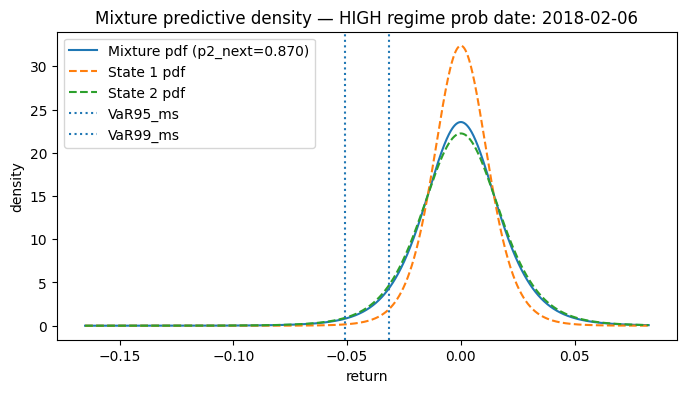

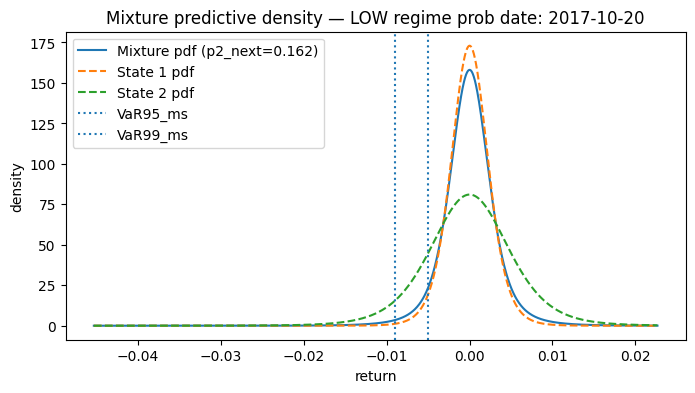

In [ ]:
# =========================
# Mixture distribution display + Mixture ES (95/99) [FAST]
# Requires: df_model, ms_params, pred_prob, h1_fwd, h2_fwd, oos with VaR95_ms/VaR99_ms
# =========================

import numpy as np
import pandas as pd
from scipy.stats import t as student_t
import matplotlib.pyplot as plt

# ---- sanity: required objects ----
assert "oos" in globals(), "oos not found
assert "df_model" in globals(), "df_model not found"
assert "ms_params" in globals(), "ms_params not found"
assert "pred_prob" in globals(), "pred_prob not found
assert "h1_fwd" in globals() and "h2_fwd" in globals(), "h1_fwd/h2_fwd not found
assert "VaR95_ms" in oos.columns and "VaR99_ms" in oos.columns,

df_model = df_model.copy().sort_index()
df_model.index = pd.to_datetime(df_model.index)
oos = oos.copy()
oos.index = pd.to_datetime(oos.index)

(w1, a1, b1, nu1) = ms_params["state1"]
(w2, a2, b2, nu2) = ms_params["state2"]

# Map OOS dates to positions in df_model
date_to_pos = pd.Series(np.arange(len(df_model)), index=df_model.index)

# ---- vectorized Student-t pdf with "unit-variance" scaling ----
def t_pdf_unit_vec(x, nu, sigma):
    """
    x: np.array
    returns pdf of t with df=nu scaled so that Var= sigma^2
    """
    scale = np.sqrt((nu - 2.0) / nu)
    y = x / (sigma * scale)
    return student_t.pdf(y, df=nu) / (sigma * scale)

def mix_pdf_vec(x, p1, s1, nu1, p2, s2, nu2):
    return p1 * t_pdf_unit_vec(x, nu1, s1) + p2 * t_pdf_unit_vec(x, nu2, s2)

# ---- ES via vectorized numerical integration: ES_alpha = E[r | r <= VaR_alpha] ----
# ES = (1/alpha) * ∫_{-∞}^{VaR} x f(x) dx
def mix_es(alpha, var_a, p1, s1, nu1, p2, s2, nu2, grid_n=800):
    if not np.isfinite(var_a):
        return np.nan
    if (not np.isfinite(s1)) or (not np.isfinite(s2)) or (s1 <= 0) or (s2 <= 0):
        return np.nan
    if (not np.isfinite(p1)) or (not np.isfinite(p2)) or (p1 < 0) or (p2 < 0):
        return np.nan
    if (not np.isfinite(nu1)) or (not np.isfinite(nu2)) or (nu1 <= 2.0) or (nu2 <= 2.0):
        return np.nan

    smax = max(float(s1), float(s2))
    lo = -12.0 * smax

    grid = np.linspace(lo, float(var_a), int(grid_n))
    pdf = mix_pdf_vec(grid, float(p1), float(s1), float(nu1), float(p2), float(s2), float(nu2))
    num = np.trapezoid(grid * pdf, grid)
    return float(num / max(alpha, 1e-12))

# ---- compute ES95/ES99 for MS-mixture on OOS dates (only where VaR exists) ----
valid_dates = oos.dropna(subset=["VaR95_ms", "VaR99_ms"]).index
ES95_ms = pd.Series(index=oos.index, dtype=float)
ES99_ms = pd.Series(index=oos.index, dtype=float)

bad = 0
for d in valid_dates:
    if d not in date_to_pos.index:
        bad += 1
        continue
    t = int(date_to_pos.loc[d])
    if t <= 0:
        bad += 1
        continue

    p1n, p2n = float(pred_prob[t, 0]), float(pred_prob[t, 1])
    s1 = float(np.sqrt(h1_fwd[t]))
    s2 = float(np.sqrt(h2_fwd[t]))

    v95 = float(oos.loc[d, "VaR95_ms"])
    v99 = float(oos.loc[d, "VaR99_ms"])

    ES95_ms.loc[d] = mix_es(0.05, v95, p1n, s1, nu1, p2n, s2, nu2, grid_n=800)
    ES99_ms.loc[d] = mix_es(0.01, v99, p1n, s1, nu1, p2n, s2, nu2, grid_n=800)

oos["ES95_ms"] = ES95_ms
oos["ES99_ms"] = ES99_ms

print("Added ES95_ms / ES99_ms ✅ | bad align rows:", bad)
print("NaN% ES95_ms =", float(oos["ES95_ms"].isna().mean()), "| NaN% ES99_ms =", float(oos["ES99_ms"].isna().mean()))

# ---- quick summary vs baseline  ----
cols_show = [c for c in ["VaR95_t","ES95_t","VaR95_ms","ES95_ms","VaR99_t","ES99_t","VaR99_ms","ES99_ms"] if c in oos.columns]
if len(cols_show) >= 4:
    print("\n=== Summary (means) ===")
    display(oos[cols_show].mean(numeric_only=True).to_frame("mean"))

# ---- Distribution display: pick 2 dates (high vs low predicted p2) and overlay PDFs ----
tmp = oos.dropna(subset=["VaR95_ms", "VaR99_ms"]).copy()
tmp["p2_next"] = np.nan

for d in tmp.index:
    if d in date_to_pos.index:
        t = int(date_to_pos.loc[d])
        if t > 0:
            tmp.loc[d, "p2_next"] = float(pred_prob[t, 1])

tmp = tmp.dropna(subset=["p2_next"])
if len(tmp) >= 10:
    d_hi = tmp["p2_next"].idxmax()
    d_lo = tmp["p2_next"].idxmin()

    def plot_mix_density(d, title):
        t = int(date_to_pos.loc[d])
        p1n, p2n = float(pred_prob[t, 0]), float(pred_prob[t, 1])
        s1 = float(np.sqrt(h1_fwd[t]))
        s2 = float(np.sqrt(h2_fwd[t]))

        smax = max(s1, s2)
        x = np.linspace(-8*smax, 4*smax, 1600)

        pdf_mix = mix_pdf_vec(x, p1n, s1, nu1, p2n, s2, nu2)
        pdf_1 = t_pdf_unit_vec(x, nu1, s1)
        pdf_2 = t_pdf_unit_vec(x, nu2, s2)

        plt.figure(figsize=(8,4))
        plt.plot(x, pdf_mix, label=f"Mixture pdf (p2_next={p2n:.3f})")
        plt.plot(x, pdf_1, label="State 1 pdf", linestyle="--")
        plt.plot(x, pdf_2, label="State 2 pdf", linestyle="--")
        plt.axvline(float(oos.loc[d, "VaR95_ms"]), linestyle=":", label="VaR95_ms")
        plt.axvline(float(oos.loc[d, "VaR99_ms"]), linestyle=":", label="VaR99_ms")
        plt.title(title)
        plt.xlabel("return")
        plt.ylabel("density")
        plt.legend()
        plt.show()

    plot_mix_density(d_hi, f"Mixture predictive density — HIGH regime prob date: {d_hi.date()}")
    plot_mix_density(d_lo, f"Mixture predictive density — LOW regime prob date: {d_lo.date()}")

else:
    print("Not enough valid rows in oos to plot mixture density (need >=10).")

In [ ]:
# =========================
# VaR backtesting (Kupiec UC + Christoffersen CC), overall & by regime
# FIXES:
# - drops NaN hits (which arise from NaN VaR) -> prevents fake 0 violation rate
# - reports n_eff (effective sample size)
# - prints NaN diagnostics for VaR columns overall and by regime
# =========================
import numpy as np
import pandas as pd
from scipy.stats import chi2

def kupiec_uc(hits, alpha):
    h = np.asarray(hits, dtype=float)
    h = h[np.isfinite(h)].astype(int)  # drop NaN
    n = len(h); x = int(h.sum())
    if n == 0:
        return np.nan, np.nan, (0, 0, np.nan)
    eps = 1e-12
    phat = np.clip(x / n, eps, 1 - eps)
    lr_uc = -2 * ((n - x) * np.log((1 - alpha) / (1 - phat)) + x * np.log(alpha / phat))
    p_uc = 1 - chi2.cdf(lr_uc, df=1)
    return float(lr_uc), float(p_uc), (x, n, float(phat))

def christoffersen_ind(hits):
    h = np.asarray(hits, dtype=float)
    h = h[np.isfinite(h)].astype(int)  # drop NaN
    if len(h) < 2:
        return np.nan, np.nan, {}
    h_lag = h[:-1]
    h_now = h[1:]
    n00 = np.sum((h_lag == 0) & (h_now == 0))
    n01 = np.sum((h_lag == 0) & (h_now == 1))
    n10 = np.sum((h_lag == 1) & (h_now == 0))
    n11 = np.sum((h_lag == 1) & (h_now == 1))

    eps = 1e-12
    pi0 = n01 / max(n00 + n01, 1)
    pi1 = n11 / max(n10 + n11, 1)
    pi  = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    def ll_bin(n0, n1, p):
        p = np.clip(p, eps, 1 - eps)
        return n1*np.log(p) + n0*np.log(1 - p)

    ll_ind = ll_bin(n00 + n10, n01 + n11, pi)
    ll_dep = ll_bin(n00, n01, pi0) + ll_bin(n10, n11, pi1)

    LR_ind = -2 * (ll_ind - ll_dep)
    p_ind  = 1 - chi2.cdf(LR_ind, df=1)
    counts = {"n00": int(n00), "n01": int(n01), "n10": int(n10), "n11": int(n11)}
    return float(LR_ind), float(p_ind), counts

def christoffersen_cc(hits, alpha):
    LR_uc, p_uc, _ = kupiec_uc(hits, alpha)
    LR_ind, p_ind, _ = christoffersen_ind(hits)
    if not np.isfinite(LR_uc) or not np.isfinite(LR_ind):
        return np.nan, np.nan, LR_uc, p_uc, LR_ind, p_ind
    LR_cc = LR_uc + LR_ind
    p_cc = 1 - chi2.cdf(LR_cc, df=2)
    return float(LR_cc), float(p_cc), float(LR_uc), float(p_uc), float(LR_ind), float(p_ind)

def backtest_block(df, hit_col, alpha):
    # drop NaN hits -> removes NaN VaR-induced fake zeros
    h = df[hit_col].to_numpy(dtype=float)
    h = h[np.isfinite(h)].astype(int)
    n_eff = len(h)
    viol = float(h.mean()) if n_eff else np.nan

    LR_uc, p_uc, (x, n, phat) = kupiec_uc(h, alpha)
    LR_cc, p_cc, _, _, LR_ind, p_ind = christoffersen_cc(h, alpha)

    out = {
        "n_eff": n_eff,
        "viol_rate": viol,
        "nominal": alpha,
        "x": x,
        "phat": phat,
        "LR_uc": LR_uc,
        "p_uc": p_uc,
        "LR_ind": LR_ind,
        "p_ind": p_ind,
        "LR_cc": LR_cc,
        "p_cc": p_cc,
    }

    # optional diagnostics if present
    for c in ["sigma_pred", "nu_pred", "VIX"]:
        if c in df.columns:
            out[f"avg_{c}"] = float(pd.to_numeric(df[c], errors="coerce").mean())
    return pd.Series(out)

def nan_diag(df, cols, group_col=None):
    if group_col is None:
        return pd.Series({c: float(df[c].isna().mean()) for c in cols})
    else:
        return df.groupby(group_col).apply(lambda g: pd.Series({c: float(g[c].isna().mean()) for c in cols}))

# --- Diagnostics: NaN rates in VaR columns ---
var_cols = [c for c in ["VaR95_t","VaR99_t","VaR95_ms","VaR99_ms"] if c in oos.columns]
print("=== NaN% in VaR columns (overall) ===")
display(nan_diag(oos, var_cols))

print("\n=== NaN% in VaR columns (by vix_regime) ===")
display(nan_diag(oos, var_cols, "vix_regime"))

# Overall backtests
overall = []
labels = []
if "hit95_t" in oos.columns:
    overall.append(backtest_block(oos, "hit95_t", 0.05)); labels.append("VaR95_tGARCH")
if "hit95_ms" in oos.columns:
    overall.append(backtest_block(oos, "hit95_ms", 0.05)); labels.append("VaR95_MS")
if "hit99_t" in oos.columns:
    overall.append(backtest_block(oos, "hit99_t", 0.01)); labels.append("VaR99_tGARCH")
if "hit99_ms" in oos.columns:
    overall.append(backtest_block(oos, "hit99_ms", 0.01)); labels.append("VaR99_MS")

bt_overall = pd.DataFrame(overall, index=labels)
print("=== Overall backtests ===")
display(bt_overall)

# By VIX regime
def bt_by(df, group_col, hit_col, alpha):
    return df.groupby(group_col).apply(lambda g: backtest_block(g, hit_col, alpha)).sort_index()

print("\n=== By vix_regime: VaR95_t ===")
display(bt_by(oos, "vix_regime", "hit95_t", 0.05))

print("\n=== By vix_regime: VaR99_t ===")
display(bt_by(oos, "vix_regime", "hit99_t", 0.01))

if "hit95_ms" in oos.columns:
    print("\n=== By vix_regime: VaR95_MS ===")
    display(bt_by(oos, "vix_regime", "hit95_ms", 0.05))

if "hit99_ms" in oos.columns:
    print("\n=== By vix_regime: VaR99_MS ===")
    display(bt_by(oos, "vix_regime", "hit99_ms", 0.01))

# By ms_state
if "ms_state" in oos.columns:
    print("\n=== By ms_state: VaR95_t ===")
    display(bt_by(oos, "ms_state", "hit95_t", 0.05))

    print("\n=== By ms_state: VaR99_t ===")
    display(bt_by(oos, "ms_state", "hit99_t", 0.01))

    if "hit95_ms" in oos.columns:
        print("\n=== By ms_state: VaR95_MS ===")
        display(bt_by(oos, "ms_state", "hit95_ms", 0.05))

    if "hit99_ms" in oos.columns:
        print("\n=== By ms_state: VaR99_MS ===")
        display(bt_by(oos, "ms_state", "hit99_ms", 0.01))

=== NaN% in VaR columns (overall) ===


,0
VaR95_t,0.0
VaR99_t,0.0
VaR95_ms,0.0
VaR99_ms,0.0



=== NaN% in VaR columns (by vix_regime) ===


/tmp/ipython-input-4218841634.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(lambda g: pd.Series({c: float(g[c].isna().mean()) for c in cols}))


,VaR95_t,VaR99_t,VaR95_ms,VaR99_ms
vix_regime,,,,
high,0.0,0.0,0.0,0.0
low,0.0,0.0,0.0,0.0
mid,0.0,0.0,0.0,0.0


...

/tmp/ipython-input-4218841634.py:126: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(lambda g: backtest_block(g, hit_col, alpha)).sort_index()


,n_eff,viol_rate,nominal,x,phat,LR_uc,p_uc,LR_ind,p_ind,LR_cc,p_cc,avg_sigma_pred,avg_nu_pred,avg_VIX
ms_state,,,,,,,,,,,,,,
0,3904.0,0.024334,0.05,95.0,0.024334,66.254952,4.440892e-16,0.19716,0.657023,66.452112,3.663736e-15,0.010064,7.713903,18.951199
1,1104.0,0.165761,0.05,183.0,0.165761,199.306518,0.000000e+00,1.41801,0.233731,200.724528,0.000000e+00,0.012136,7.367132,21.418895



=== By ms_state: VaR99_MS ===


/tmp/ipython-input-4218841634.py:126: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(lambda g: backtest_block(g, hit_col, alpha)).sort_index()


,n_eff,viol_rate,nominal,x,phat,LR_uc,p_uc,LR_ind,p_ind,LR_cc,p_cc,avg_sigma_pred,avg_nu_pred,avg_VIX
ms_state,,,,,,,,,,,,,,
0,3904.0,0.001793,0.01,7.0,0.001793,40.283404,2.196672e-10,0.025154,0.873984,40.308558,1.766477e-09,0.010064,7.713903,18.951199
1,1104.0,0.057065,0.01,63.0,0.057065,118.033134,0.000000e+00,1.534831,0.215389,119.567965,0.000000e+00,0.012136,7.367132,21.418895


/tmp/ipython-input-171472503.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(lambda g: backtest_block(g, hit_col, alpha)).sort_index()
/tmp/ipython-input-171472503.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(lambda g: backtest_block(g, hit_col, alpha)).sort_index()
/tmp/ipython-input-171472503.py:18: DeprecationWarning: Data

,vix_regime,tag,alpha,nominal,viol_rate_t,viol_rate_ms
0,high,VaR95,0.05,0.05,0.118432,0.106756
1,low,VaR95,0.05,0.05,0.029766,0.031650
2,mid,VaR95,0.05,0.05,0.061472,0.057143
3,high,VaR99,0.01,0.01,0.036697,0.032527
4,low,VaR99,0.01,0.01,0.004898,0.004898
5,mid,VaR99,0.01,0.01,0.016450,0.015584


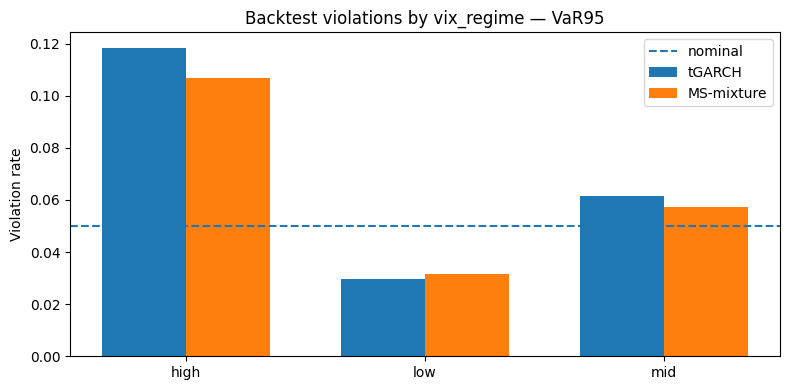

Saved: figures/backtest_violation_by_vix_var95.png


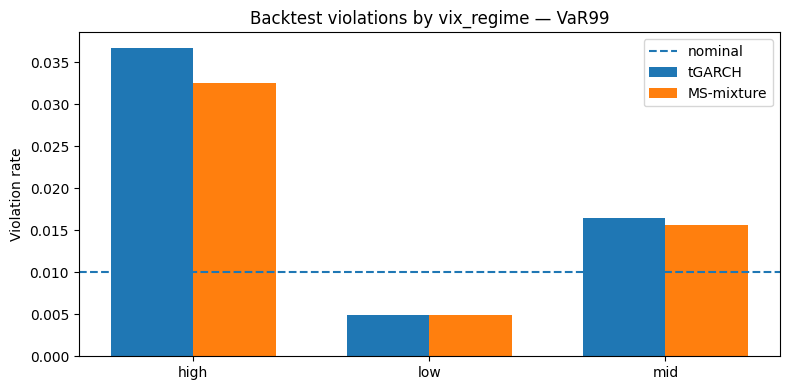

Saved: figures/backtest_violation_by_vix_var99.png


In [ ]:
# =========================
# Backtest failure bar charts by vix_regime (tGARCH vs MS-mixture)
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "oos" in globals(), "oos not found."
assert "vix_regime" in oos.columns, "oos missing vix_regime."

os.makedirs("figures", exist_ok=True)

def bt_by(df, group_col, hit_col, alpha):
    return df.groupby(group_col).apply(lambda g: backtest_block(g, hit_col, alpha)).sort_index()

def collect_viol_rates():
    rows = []
    for alpha, hit_t, hit_ms, tag in [
        (0.05, "hit95_t", "hit95_ms", "VaR95"),
        (0.01, "hit99_t", "hit99_ms", "VaR99"),
    ]:
        if hit_t in oos.columns:
            bt_t = bt_by(oos, "vix_regime", hit_t, alpha)
            bt_t = bt_t.reset_index().rename(columns={"viol_rate": "viol_rate_t"})
        else:
            bt_t = None

        if hit_ms in oos.columns:
            bt_m = bt_by(oos, "vix_regime", hit_ms, alpha)
            bt_m = bt_m.reset_index().rename(columns={"viol_rate": "viol_rate_ms"})
        else:
            bt_m = None

        if bt_t is None or bt_m is None:
            print(f"Skip {tag}: missing columns.")
            continue

        m = bt_t.merge(bt_m, on="vix_regime", how="inner")
        m["alpha"] = alpha
        m["tag"] = tag
        m["nominal"] = alpha
        rows.append(m[["vix_regime","tag","alpha","nominal","viol_rate_t","viol_rate_ms"]])

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

viol = collect_viol_rates()
display(viol)

# Plot: two panels (VaR95 and VaR99)
for tag in viol["tag"].unique():
    sub = viol[viol["tag"] == tag].copy()
    sub = sub.sort_values("vix_regime")

    regimes = sub["vix_regime"].tolist()
    x = np.arange(len(regimes))
    width = 0.35

    fig = plt.figure(figsize=(8, 4))
    ax = plt.gca()
    ax.bar(x - width/2, sub["viol_rate_t"].to_numpy(), width, label="tGARCH")
    ax.bar(x + width/2, sub["viol_rate_ms"].to_numpy(), width, label="MS-mixture")
    ax.axhline(float(sub["nominal"].iloc[0]), linestyle="--", label="nominal")

    ax.set_xticks(x)
    ax.set_xticklabels(regimes)
    ax.set_ylabel("Violation rate")
    ax.set_title(f"Backtest violations by vix_regime — {tag}")
    ax.legend()

    plt.tight_layout()
    out = f"figures/backtest_violation_by_vix_{tag.lower()}.png"
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

In [ ]:
# =========================
# Transition event study: violations, sigma_pred, and (optional) xi
# =========================
import numpy as np
import pandas as pd

assert "df_model" in globals(), "df_model not found."
assert "oos" in globals(), "oos not found."

WINDOW = globals().get("WINDOW", 10)
K_LOW_RUN = globals().get("K_LOW_RUN", 5)

# --- Use OOS table (has hits + regime) as baseline for event study ---
res = oos.copy().sort_index()
idx = res.index

# low-run count on vix_regime
is_low = (res["vix_regime"] == "low").astype(int)
grp = (is_low == 0).cumsum()
res["low_run"] = is_low.groupby(grp).cumsum()

# strict transitions: today high, yesterday low, yesterday low_run>=k
flag = (
    (res["vix_regime"] == "high") &
    (res["vix_regime"].shift(1) == "low") &
    (res["low_run"].shift(1) >= K_LOW_RUN)
)
trans_dates = res.index[flag.fillna(False)]
trans_dates = pd.to_datetime(trans_dates)

# de-overlap transitions (avoid overlapping windows)
keep = []
last_pos = -10**9
for d in trans_dates:
    pos = idx.get_loc(d)
    if pos - last_pos > WINDOW:
        keep.append(d)
        last_pos = pos
trans_dates = pd.to_datetime(keep)

print("Strict low->high transitions:", len(trans_dates))
print("First 5:", trans_dates[:5].tolist())


use_xi = ("xi_daily" in globals()) and ("xi" in xi_daily.columns)
if use_xi:
    res = res.join(xi_daily[["xi"]], how="left")

def window_slice(center_date, w):
    pos = idx.get_loc(center_date)
    start = max(0, pos - w)
    end = min(len(idx) - 1, pos + w)
    win = res.iloc[start:end+1].copy()
    win["tau"] = np.arange(start - pos, start - pos + len(win))
    win = win[(win["tau"] >= -w) & (win["tau"] <= w)]
    return win

rows = []
for d in trans_dates:
    win = window_slice(d, WINDOW)
    rows.append(win[["tau","sigma_pred","hit95_t","hit99_t","VIX","nu_pred"] + (["xi"] if use_xi else [])].copy())

event_panel = pd.concat(rows, ignore_index=True)

agg_dict = {
    "avg_sigma_pred": ("sigma_pred","mean"),
    "viol95_rate": ("hit95_t","mean"),
    "viol99_rate": ("hit99_t","mean"),
    "avg_VIX": ("VIX","mean"),
    "avg_nu": ("nu_pred","mean"),
    "n": ("sigma_pred","size"),
}
if use_xi:
    agg_dict["avg_xi"] = ("xi","mean")

event_profile = event_panel.groupby("tau").agg(**agg_dict).reset_index()
display(event_profile)

# Simple pre/post summary
pre = event_panel[(event_panel["tau"] >= -WINDOW) & (event_panel["tau"] <= -1)]
post = event_panel[(event_panel["tau"] >= 0) & (event_panel["tau"] <= WINDOW)]
summ = {
    "period": ["pre","post"],
    "avg_sigma_pred": [pre["sigma_pred"].mean(), post["sigma_pred"].mean()],
    "viol95_rate": [pre["hit95_t"].mean(), post["hit95_t"].mean()],
    "viol99_rate": [pre["hit99_t"].mean(), post["hit99_t"].mean()],
    "avg_VIX": [pre["VIX"].mean(), post["VIX"].mean()],
    "avg_nu": [pre["nu_pred"].mean(), post["nu_pred"].mean()],
    "n": [len(pre), len(post)]
}
if use_xi:
    summ["avg_xi"] = [pre["xi"].mean(), post["xi"].mean()]

summary_prepost = pd.DataFrame(summ)
print("\n=== Pre vs Post transition summary ===")
display(summary_prepost)


Strict low->high transitions: 2
First 5: [Timestamp('2018-05-29 00:00:00'), Timestamp('2024-12-18 00:00:00')]


,tau,avg_sigma_pred,viol95_rate,viol99_rate,avg_VIX,avg_nu,n
0,-10,0.006956,0.0,0.0,13.190000,7.067345,2
1,-9,0.006708,0.0,0.0,14.085000,7.061661,2
2,-8,0.006645,0.0,0.0,13.095000,7.026766,2
3,-7,0.006371,0.0,0.0,13.810000,6.994525,2
4,-6,0.006156,0.0,0.0,13.800000,6.999031,2
5,-5,0.005917,0.0,0.0,13.330000,6.946854,2
6,-4,0.006428,0.0,0.0,13.570000,6.998993,2
7,-3,0.006259,0.0,0.0,13.195000,7.013928,2
8,-2,0.005965,0.0,0.0,13.610000,6.982306,2
9,-1,0.005793,0.0,0.0,14.545000,6.967684,2



=== Pre vs Post transition summary ===


,period,avg_sigma_pred,viol95_rate,viol99_rate,avg_VIX,avg_nu,n
0,pre,0.006320,0.000000,0.000000,13.623000,7.005909,20
1,post,0.009007,0.090909,0.045455,15.783636,6.622625,22


In [ ]:
# Forecast instability
def instab_desc(g):
    return pd.Series({
        "n": len(g),
        "mean_sigma_pred": g["sigma_pred"].mean(),
        "mean_abs_ret": g["abs_ret"].mean(),
        "mean_err_absret": g["err_absret"].mean(),
        "median_err_ratio": g["err_ratio"].median(),
        "P(err_ratio>2)": (g["err_ratio"] > 2).mean(),  # big miss
    })

print("=== Forecast instability by VIX regime ===")
display(roll.groupby("vix_regime").apply(instab_desc).sort_index())

print("=== Forecast instability by policy regime ===")
display(roll.groupby("policy_regime").apply(instab_desc).sort_index())


if "ms_p2" in roll.columns:
    tmp = roll.copy()
    tmp["ms_p2_bin"] = pd.qcut(tmp["ms_p2"], q=4, labels=["Q1(low)", "Q2", "Q3", "Q4(high)"])
    print("=== Forecast instability by ms_p2 quartiles ===")
    display(tmp.groupby("ms_p2_bin").apply(instab_desc))



=== Forecast instability by VIX regime ===


/tmp/ipython-input-196536350.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(roll.groupby("vix_regime").apply(instab_desc).sort_index())


,n,mean_sigma_pred,mean_abs_ret,mean_err_absret,median_err_ratio,P(err_ratio>2)
vix_regime,,,,,,
high,1199.0,0.017479,0.014756,-0.002723,0.709004,0.093411
low,2654.0,0.007529,0.004833,-0.002696,0.493610,0.025998
mid,1155.0,0.010171,0.007498,-0.002673,0.590503,0.058009


/tmp/ipython-input-196536350.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(roll.groupby("policy_regime").apply(instab_desc).sort_index())


=== Forecast instability by policy regime ===


...

/tmp/ipython-input-196536350.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(roll.groupby("ms_state").apply(instab_desc).sort_index())


,n,mean_sigma_pred,mean_abs_ret,mean_err_absret,median_err_ratio,P(err_ratio>2)
ms_state,,,,,,
0,3904.0,0.010064,0.006361,-0.003702,0.475098,0.019211
1,1104.0,0.012136,0.012993,0.000857,1.064023,0.156703


=== Forecast instability by ms_p2 quartiles ===


/tmp/ipython-input-196536350.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(tmp.groupby("ms_p2_bin").apply(instab_desc))
/tmp/ipython-input-196536350.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(tmp.groupby("ms_p2_bin").apply(instab_desc))


,n,mean_sigma_pred,mean_abs_ret,mean_err_absret,median_err_ratio,P(err_ratio>2)
ms_p2_bin,,,,,,
Q1(low),1252.0,0.007176,0.003472,-0.003704,0.338356,0.013578
Q2,1252.0,0.011164,0.006984,-0.004181,0.508077,0.015176
Q3,1252.0,0.011690,0.008194,-0.003496,0.642749,0.024760
Q4(high),1252.0,0.012051,0.012644,0.000592,1.027035,0.144569


In [ ]:
# --- ADD: same regression with MS-state instead of VIX-regime dummies (FIX overlap) ---
import pandas as pd
import statsmodels.api as sm

df_err2 = roll.copy()

# Ensure datetime index alignment (safety)
df_err2.index = pd.to_datetime(df_err2.index)
dm = df_model.copy()
dm.index = pd.to_datetime(dm.index)

df_err2 = df_err2.join(dm[["policy_shock_3m_z"]], how="left", rsuffix="_dm")

need_ms = [c for c in ["ms_state", "ms_p2"] if c not in df_err2.columns]
if len(need_ms) > 0:
    df_err2 = df_err2.join(dm[need_ms], how="left", rsuffix="_dm2")

df_err2["shock"] = pd.to_numeric(df_err2["policy_shock_3m_z"], errors="coerce").clip(-5, 5)

# MS dummy / probability
df_err2["D_ms2"] = (pd.to_numeric(df_err2["ms_state"], errors="coerce") == 1).astype(int)
df_err2["abs_error"] = (df_err2["abs_ret"] - df_err2["sigma_pred"]).abs()

df_err2 = df_err2.dropna(subset=["abs_error", "D_ms2", "shock", "sigma_pred"]).copy()

X2 = pd.DataFrame({
    "const": 1.0,
    "D_ms2": df_err2["D_ms2"],
    "shock": df_err2["shock"],
    "sigma_pred": df_err2["sigma_pred"],
    # optional continuous state prob
    # "ms_p2": df_err2["ms_p2"],
}, index=df_err2.index)

y2 = df_err2["abs_error"]

ols_err_ms = sm.OLS(y2, X2).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print("\n=== Error structure regression (MS-state version) ===")
print(ols_err_ms.summary())



=== Error structure regression (MS-state version) ===
                            OLS Regression Results                            
Dep. Variable:              abs_error   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     172.5
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          1.96e-106
Time:                        04:09:14   Log-Likelihood:                 19719.
No. Observations:                5008   AIC:                        -3.943e+04
Df Residuals:                    5004   BIC:                        -3.940e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [ ]:
# Regime-dependent Mincer-Zarnowitz test

df_mz = roll.copy()

df_mz["D_high"] = (df_mz["vix_regime"]=="high").astype(int)
df_mz["D_mid"]  = (df_mz["vix_regime"]=="mid").astype(int)

df_mz = df_mz.dropna(subset=["abs_ret","sigma_pred"])

df_mz["sigma_x_high"] = df_mz["sigma_pred"] * df_mz["D_high"]
df_mz["sigma_x_mid"]  = df_mz["sigma_pred"] * df_mz["D_mid"]

X = pd.DataFrame({
    "const":1.0,
    "sigma_pred":df_mz["sigma_pred"],
    "D_high":df_mz["D_high"],
    "D_mid":df_mz["D_mid"],
    "sigma_x_high":df_mz["sigma_x_high"],
    "sigma_x_mid":df_mz["sigma_x_mid"],
})

y = df_mz["abs_ret"]

mz = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":5})
print(mz.summary())


                            OLS Regression Results                            
Dep. Variable:                abs_ret   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     189.5
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          2.36e-185
Time:                        04:09:14   Log-Likelihood:                 17180.
No. Observations:                5008   AIC:                        -3.435e+04
Df Residuals:                    5002   BIC:                        -3.431e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0012      0.000      3.493   

In [ ]:
# Rolling EVT ξ(t)(POT-GPD) shape parameter xi(t)
from scipy.stats import genpareto

EVT_WIN   = 1260   # ~5y
EVT_STEP  = 5      # speed;
EVT_Q     = 0.95   # POT threshold on LOSS (top 5%)
MIN_EXC   = 50     # min exceedances for stable fit

tmp = df_model.copy().sort_index()
tmp["loss"] = -tmp["ret"]  # positive loss

xi_list, date_list = [], []
idx_evt = tmp.index

for i in range(EVT_WIN, len(tmp), EVT_STEP):
    win = tmp.iloc[i-EVT_WIN:i]
    d   = idx_evt[i]

    L = win["loss"].dropna().values
    if len(L) < 500:
        continue

    u = np.quantile(L, EVT_Q)
    exc = L[L > u] - u

    if len(exc) < MIN_EXC:
        continue

    try:
        xi, loc, beta = genpareto.fit(exc, floc=0.0)  # force loc=0
    except Exception:
        continue

    xi_list.append(float(xi))
    date_list.append(d)

xi_roll = pd.DataFrame({"xi": xi_list}, index=pd.to_datetime(date_list)).sort_index()

# align to daily index (carry last estimate forward)
xi_daily = df_model[[]].join(xi_roll, how="left")
xi_daily["xi"] = xi_daily["xi"].ffill()

print("xi_daily available:", xi_daily["xi"].notna().mean(), "share of days")
print(xi_daily.dropna().head())


xi_daily available: 0.7989789406509253 share of days
                  xi
2006-02-03 -0.020173
2006-02-06 -0.020173
2006-02-07 -0.020173
2006-02-08 -0.020173
2006-02-09 -0.020173


In [ ]:
# Transition identification
import numpy as np
import pandas as pd

res = df_model.copy().sort_index()
res.index = pd.to_datetime(res.index)
idx = res.index

# ---- settings ----
STRICT_LOOKBACK = 5
RELAX_LOOKBACK  = 10
Z_CUT = -3.0  # robustness: try -2.5 as well
DEOVERLAP = True

# --- low-run count ---
is_low = (res["vix_regime"] == "low").astype(int)
grp = (is_low == 0).cumsum()
res["low_run"] = is_low.groupby(grp).cumsum()

def get_transitions_v2(k_low_run=5, lookback_days=5, deoverlap=True, window=10):
    """
    Event day t is HIGH, and within the last `lookback_days` days there exists a LOW day
    where low_run >= k_low_run. Keep only the FIRST HIGH day of each high cluster.
    Optionally remove overlapping event windows (distance <= window).
    """
    v = res["vix_regime"]

    is_high_today = (v == "high").astype(bool)

    # within past L days, exists low day with sufficient low_run
    cond_prev_lowrun = np.zeros(len(res), dtype=bool)
    for lag in range(1, lookback_days + 1):
        ok = ((v.shift(lag) == "low") & (res["low_run"].shift(lag) >= k_low_run))
        cond_prev_lowrun |= ok.fillna(False).to_numpy(dtype=bool)

    # first day of a high-cluster (no fillna/downcast warning)
    prev_high = is_high_today.shift(1, fill_value=False)
    first_high = is_high_today & (~prev_high)

    flag = is_high_today & cond_prev_lowrun & first_high
    dates = pd.to_datetime(res.index[flag])

    if deoverlap and len(dates) > 0:
        keep = []
        last_pos = -10**9
        for d in dates:
            pos = idx.get_loc(d)
            if pos - last_pos > window:
                keep.append(d)
                last_pos = pos
        dates = pd.to_datetime(keep)

    return dates

strict_dates  = get_transitions_v2(k_low_run=K_LOW_RUN, lookback_days=STRICT_LOOKBACK, deoverlap=DEOVERLAP, window=WINDOW)
relaxed_dates = get_transitions_v2(k_low_run=max(3, K_LOW_RUN-2), lookback_days=RELAX_LOOKBACK, deoverlap=DEOVERLAP, window=WINDOW)

print("Strict transitions:", len(strict_dates), "first 5:", strict_dates[:5].tolist())
print("Relaxed transitions:", len(relaxed_dates), "first 5:", relaxed_dates[:5].tolist())

def build_event_profile(dates, window=10, use_roll=None, xi_daily=None, z_cut=-3.0):
    rows = []

    # Prepare roll (avoid overlaps by renaming)
    roll_small = None
    if use_roll is not None:
        roll_small = use_roll.copy()
        roll_small.index = pd.to_datetime(roll_small.index)
        rename_map = {"sigma_pred": "sigma_pred_oos", "err_ratio": "err_ratio_oos", "err_absret": "err_absret_oos"}
        cols_keep = [c for c in ["sigma_pred", "err_ratio", "err_absret"] if c in roll_small.columns]
        roll_small = roll_small[cols_keep].rename(columns=rename_map)

    # Prepare xi_daily
    xi_small = None
    if xi_daily is not None:
        xi_small = xi_daily.copy()
        xi_small.index = pd.to_datetime(xi_small.index)
        xi_small = xi_small.to_frame("xi") if "xi" not in xi_small.columns else xi_small[["xi"]]

    for d in dates:
        pos = idx.get_loc(d)
        start = max(0, pos - window)
        end   = min(len(idx) - 1, pos + window)

        win = res.iloc[start:end+1].copy()
        win["tau"] = np.arange(start - pos, start - pos + len(win))
        win = win[(win["tau"] >= -window) & (win["tau"] <= window)]

        # merge aux tables
        if roll_small is not None:
            win = win.join(roll_small, how="left")
        if xi_small is not None:
            win = win.join(xi_small, how="left")
        else:
            win["xi"] = np.nan

        # prefer OOS sigma for z, fallback to sigma_garch
        if "sigma_pred_oos" in win.columns:
            sig_used = pd.to_numeric(win["sigma_pred_oos"], errors="coerce").fillna(pd.to_numeric(win["sigma_garch"], errors="coerce"))
        else:
            sig_used = pd.to_numeric(win["sigma_garch"], errors="coerce")

        win["z_used"] = pd.to_numeric(win["ret"], errors="coerce") / (sig_used + 1e-12)
        win["I_ext"] = (win["z_used"] < z_cut).astype(int)

        def col_or_nan(c):
            return win[c] if c in win.columns else np.nan

        rows.append(pd.DataFrame({
            "tau": win["tau"].to_numpy(),
            "ret": col_or_nan("ret"),
            "sigma_garch": col_or_nan("sigma_garch"),
            "VIX": col_or_nan("VIX"),
            "xi": col_or_nan("xi"),
            "I_ext": win["I_ext"].to_numpy(),
            "policy_regime": col_or_nan("policy_regime"),
            "vix_regime": col_or_nan("vix_regime"),
            "sigma_pred_oos": col_or_nan("sigma_pred_oos"),
            "err_ratio_oos": col_or_nan("err_ratio_oos"),
            "err_absret_oos": col_or_nan("err_absret_oos"),
        }))

    panel = pd.concat(rows, ignore_index=True)

    prof = panel.groupby("tau").agg(
        avg_ret=("ret", "mean"),
        avg_sigma=("sigma_garch", "mean"),
        avg_vix=("VIX", "mean"),
        avg_xi=("xi", "mean"),
        extreme_rate=("I_ext", "mean"),
        avg_sigma_pred_oos=("sigma_pred_oos", "mean"),
        avg_err_ratio_oos=("err_ratio_oos", "mean"),
        n=("ret", "size"),
    ).reset_index()

    meta = {
        "n_events": int(len(dates)),
        "n_tau0": int((panel["tau"] == 0).sum()),
        "z_cut": float(z_cut),
    }
    return prof, panel, meta

prof_strict, panel_strict, meta_strict = build_event_profile(
    strict_dates, window=WINDOW, use_roll=roll, xi_daily=xi_daily if "xi_daily" in globals() else None, z_cut=Z_CUT
)
prof_relax, panel_relax, meta_relax = build_event_profile(
    relaxed_dates, window=WINDOW, use_roll=roll, xi_daily=xi_daily if "xi_daily" in globals() else None, z_cut=Z_CUT
)

print("\n=== Event profile (STRICT) ===")
print("meta:", meta_strict)
display(prof_strict)

print("\n=== Event profile (RELAXED) ===")
print("meta:", meta_relax)
display(prof_relax)

Strict transitions: 19 first 5: [Timestamp('2011-03-16 00:00:00'), Timestamp('2014-10-13 00:00:00'), Timestamp('2014-12-16 00:00:00'), Timestamp('2015-08-21 00:00:00'), Timestamp('2015-11-13 00:00:00')]
Relaxed transitions: 25 first 5: [Timestamp('2001-02-22 00:00:00'), Timestamp('2001-09-06 00:00:00'), Timestamp('2010-05-06 00:00:00'), Timestamp('2011-03-16 00:00:00'), Timestamp('2011-08-04 00:00:00')]

=== Event profile (STRICT) ===
meta: {'n_events': 19, 'n_tau0': 19, 'z_cut': -3.0}


,tau,avg_ret,avg_sigma,avg_vix,avg_xi,extreme_rate,avg_sigma_pred_oos,avg_err_ratio_oos,n
0,-10,0.001971,0.007436,14.687895,0.087556,0.000000,0.007318,0.563328,19
1,-9,0.002591,0.007251,14.478947,0.087556,0.000000,0.007133,0.712170,19
2,-8,-0.001247,0.007249,14.551053,0.087505,0.000000,0.007150,0.680857,19
3,-7,0.000119,0.007340,14.632632,0.087108,0.000000,0.007211,0.492482,19
4,-6,0.001833,0.007111,14.440000,0.075769,0.000000,0.006967,0.736337,19
5,-5,0.001347,0.007139,14.532632,0.075446,0.000000,0.007029,0.482547,19
6,-4,-0.008518,0.006960,16.173158,0.075446,0.052632,0.006881,1.344564,19
7,-3,0.002314,0.007657,15.981053,0.076788,0.000000,0.007597,0.759271,19
8,-2,-0.004648,0.007716,16.977368,0.078057,0.000000,0.007687,0.830168,19
9,-1,-0.006966,0.007892,18.384737,0.077326,0.052632,0.007928,1.058234,19



=== Event profile (RELAXED) ===
meta: {'n_events': 25, 'n_tau0': 25, 'z_cut': -3.0}


,tau,avg_ret,avg_sigma,avg_vix,avg_xi,extreme_rate,avg_sigma_pred_oos,avg_err_ratio_oos,n
0,-10,0.001714,0.007937,15.8076,0.098790,0.00,0.007525,0.631167,25
1,-9,0.001582,0.007796,15.6148,0.099375,0.00,0.007399,0.673574,25
2,-8,-0.001299,0.007723,15.7452,0.099333,0.00,0.007367,0.669412,25
3,-7,-0.001405,0.007831,16.1500,0.099005,0.04,0.007401,0.666041,25
4,-6,0.001189,0.007807,15.9608,0.089638,0.00,0.007342,0.893708,25
5,-5,0.000366,0.008002,16.1164,0.090902,0.00,0.007548,0.553006,25
6,-4,-0.008276,0.007843,17.6516,0.090902,0.04,0.007446,1.262980,25
7,-3,0.001261,0.008430,17.4584,0.092209,0.00,0.008050,0.824250,25
8,-2,-0.007120,0.008581,18.6576,0.093257,0.00,0.008176,0.962741,25
9,-1,-0.006241,0.008936,19.8180,0.092653,0.04,0.008574,0.977395,25


In [ ]:
# -------- Sanity checks for event study --------
def sanity_event(prof, panel, name):
    print(f"\n[Sanity] {name}")
    print("Num events approx =", panel[panel["tau"] == 0].shape[0], "(rows at tau=0)")
    print("Panel shape:", panel.shape)

    # tau-level sample size summary
    n_by_tau = prof.set_index("tau")["n"]
    print("n (tau-level) min/median/max:", int(n_by_tau.min()), float(n_by_tau.median()), int(n_by_tau.max()))

    # extreme sparsity
    ex = prof.set_index("tau")["extreme_rate"]
    print("extreme_rate nonzero taus:", int((ex > 0).sum()), "out of", len(ex))
    print("extreme_rate max:", float(ex.max()))

    # if too sparse, suggest a softer threshold
    if float(ex.max()) <= 0.05 and float(n_by_tau.median()) < 30:
        print("⚠️  Extreme events are very sparse with current definition (z<-3). Consider also z<-2.5 robustness.")

sanity_event(prof_strict, panel_strict, "STRICT transitions")
sanity_event(prof_relax,  panel_relax,  "RELAXED transitions")


[Sanity] STRICT transitions
Num events approx = 19 (rows at tau=0)
Panel shape: (399, 11)
n (tau-level) min/median/max: 19 19.0 19
extreme_rate nonzero taus: 6 out of 21
extreme_rate max: 0.3157894736842105

[Sanity] RELAXED transitions
Num events approx = 25 (rows at tau=0)
Panel shape: (525, 11)
n (tau-level) min/median/max: 25 25.0 25
extreme_rate nonzero taus: 9 out of 21
extreme_rate max: 0.28


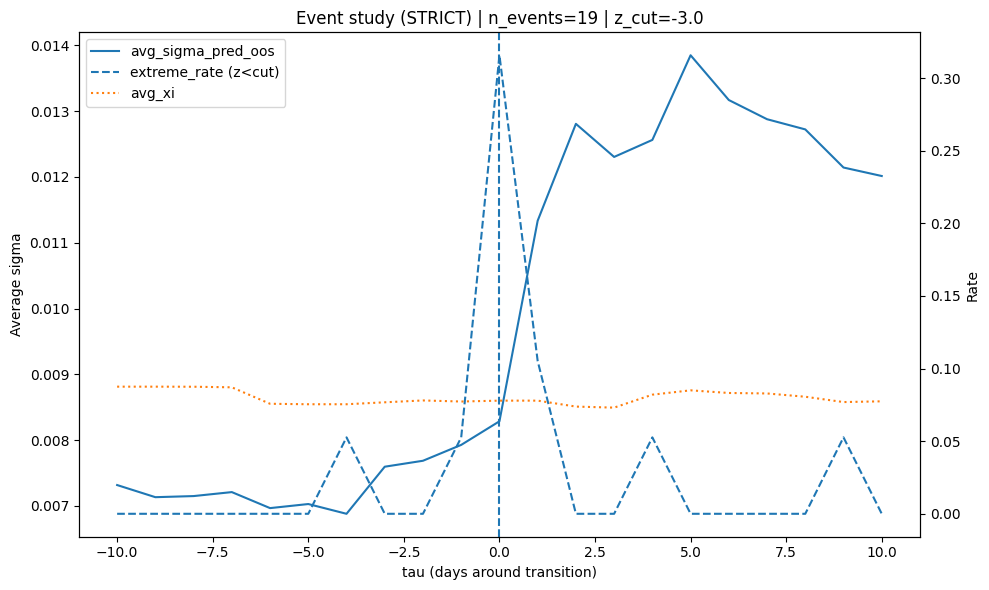

Saved: figures/event_study_strict.png


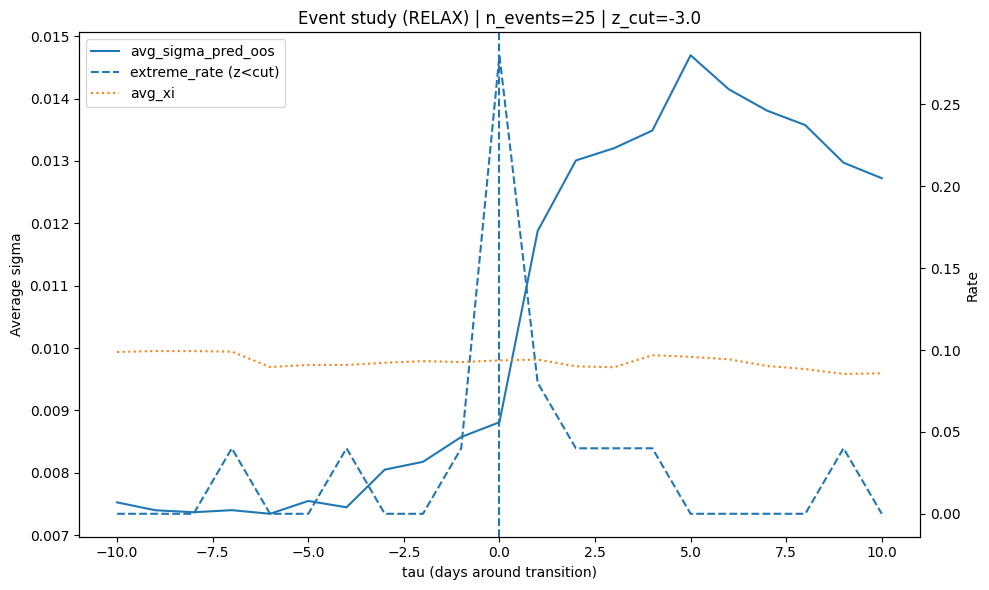

Saved: figures/event_study_relax.png


In [ ]:
# =========================
# Event-study main figures (average paths)s
# =========================
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

def plot_event_profile(prof, meta, name_prefix):
    prof = prof.sort_values("tau").copy()
    tau = prof["tau"].to_numpy()

    def col(c):
        return prof[c].to_numpy() if c in prof.columns else None

    fig = plt.figure(figsize=(10, 6))
    ax1 = plt.gca()

    y_sigma = col("avg_sigma_pred_oos")
    sigma_label = "avg_sigma_pred_oos"
    if y_sigma is None:
        y_sigma = col("avg_sigma")
        sigma_label = "avg_sigma_garch"
    ax1.plot(tau, y_sigma, label=sigma_label)
    ax1.axvline(0, linestyle="--")
    ax1.set_xlabel("tau (days around transition)")
    ax1.set_ylabel("Average sigma")

    # 2) right axis: violations/extreme rate
    ax2 = ax1.twinx()
    y_ext = col("extreme_rate")
    if y_ext is not None:
        ax2.plot(tau, y_ext, linestyle="--", label="extreme_rate (z<cut)")
        ax2.set_ylabel("Rate")

    # 3) optional xi
    y_xi = col("avg_xi")
    if y_xi is not None:
        ax2.plot(tau, y_xi, linestyle=":", label="avg_xi")

    # Title + legend
    title = f"Event study ({name_prefix}) | n_events={meta.get('n_events', 'NA')} | z_cut={meta.get('z_cut', 'NA')}"
    plt.title(title)

    # merge legends
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    out = f"figures/event_study_{name_prefix.lower()}.png"
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# Plot STRICT and RELAX
plot_event_profile(prof_strict, meta_strict if "meta_strict" in globals() else {}, "STRICT")
plot_event_profile(prof_relax,  meta_relax  if "meta_relax"  in globals() else {}, "RELAX")

In [ ]:
# Rolling tail frequency（z<-3）

import numpy as np
import pandas as pd

TAIL_WIN = 252
df_tf = df_model.copy().sort_index()
df_tf.index = pd.to_datetime(df_tf.index)

# Prefer OOS sigma_pred from roll if available (avoid look-ahead); fallback to sigma_garch
use_oos = ("roll" in globals()) and (hasattr(roll, "columns")) and ("sigma_pred" in roll.columns)

if use_oos:
    sig = roll[["sigma_pred"]].copy()
    sig.index = pd.to_datetime(sig.index)
    sig = sig.rename(columns={"sigma_pred": "sigma_pred_oos"})

    # join safely (no column collision)
    df_tf = df_tf.join(sig, how="left")

    # z uses OOS sigma when present, else fallback
    sigma_used = df_tf["sigma_pred_oos"].astype(float).fillna(df_tf["sigma_garch"].astype(float))
    df_tf["z_used"] = df_tf["ret"].astype(float) / (sigma_used + 1e-12)

df_tf["I_z_lt_-3"] = (df_tf["z_used"] < -3).astype(int)
df_tf["tail_rate_1y"] = df_tf["I_z_lt_-3"].rolling(TAIL_WIN).mean().shift(1)

print(df_tf[["tail_rate_1y"]].dropna().head())

# Optional quick diagnostic
if use_oos:
    print("NaN% sigma_pred_oos =", float(df_tf["sigma_pred_oos"].isna().mean()))

Cell 13: tail z uses OOS sigma_pred_oos (fallback to sigma_garch) ✅
            tail_rate_1y
2002-02-04      0.007937
2002-02-05      0.007937
2002-02-06      0.007937
2002-02-07      0.007937
2002-02-08      0.007937
NaN% sigma_pred_oos = 0.20102105934907466


In [ ]:
# supF structural break test around transitions (mean equation)
# + Monte Carlo critical values & p-values (thesis-level)

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# -------------------------
# 0) sanity checks
# -------------------------
assert "vix_regime" in df_model.columns, "df_model missing vix_regime"
assert "ret" in df_model.columns, "df_model missing ret"
assert "sigma_garch" in df_model.columns, "df_model missing sigma_garch"
assert "VIX" in df_model.columns, "df_model missing VIX"

# -------------------------
# 1) supF test (Quandt-Andrews / sup-Wald) for OLS break in ALL coefficients
# -------------------------
def supF_test_ols(y, X, trim=0.15):
    """
    Quandt-Andrews sup-F for one break in all coefficients (Chow-type).
    y: (T,)
    X: (T,k) includes constant
    returns: supF, break_index, n_obs, n_candidates
    """
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    T, k = X.shape

    # minimal size guard
    if T <= max(40, 2*k + 20):
        return np.nan, None, int(T), 0

    # pooled SSR
    m0 = sm.OLS(y, X).fit()
    SSR0 = float(np.sum(m0.resid**2))

    lo = int(np.floor(trim * T))
    hi = int(np.ceil((1 - trim) * T))
    cand = range(lo, hi)

    bestF, bestt = -np.inf, None
    n_cand = 0

    for t in cand:
        y1, X1 = y[:t], X[:t, :]
        y2, X2 = y[t:], X[t:, :]

        if len(y1) <= k + 5 or len(y2) <= k + 5:
            continue

        m1 = sm.OLS(y1, X1).fit()
        m2 = sm.OLS(y2, X2).fit()

        SSR1 = float(np.sum(m1.resid**2))
        SSR2 = float(np.sum(m2.resid**2))

        # Chow-type F: restrictions = k (all coeffs equal)
        num = (SSR0 - (SSR1 + SSR2)) / k
        den = (SSR1 + SSR2) / (T - 2 * k)

        if den <= 0:
            continue

        Fstat = num / den
        n_cand += 1

        if Fstat > bestF:
            bestF, bestt = Fstat, t

    if n_cand == 0:
        return np.nan, None, int(T), 0

    return float(bestF), int(bestt), int(T), int(n_cand)

def build_mean_X(df_):
    """
    Mean equation design matrix.
    ret_fwd1 = b0 + b1*risk + b2*D_high + b3*D_mid + b4*risk*D_high + b5*risk*D_mid + error
    """
    D_high = (df_["vix_regime"] == "high").astype(int)
    D_mid  = (df_["vix_regime"] == "mid").astype(int)
    risk   = df_["sigma_garch"].astype(float)

    X = pd.DataFrame({
        "const": 1.0,
        "risk": risk,
        "D_high": D_high,
        "D_mid": D_mid,
        "risk_x_high": risk * D_high,
        "risk_x_mid":  risk * D_mid,
    }, index=df_.index)
    return X

# -------------------------
# 2) build RELAXED transition dates
# -------------------------
res = df_model.copy().sort_index()
idx = res.index

if "K_LOW_RUN" not in globals():
    K_LOW_RUN = 5
if "WINDOW" not in globals():
    WINDOW = 60

is_low = (res["vix_regime"] == "low").astype(int)
grp = (is_low == 0).cumsum()
res["low_run"] = is_low.groupby(grp).cumsum()

k_relax = max(3, K_LOW_RUN - 2)

relaxed_flag = (
    (res["vix_regime"] == "high") &
    (
        ((res["vix_regime"].shift(1) == "low") & (res["low_run"].shift(1) >= k_relax)) |
        ((res["vix_regime"].shift(2) == "low") & (res["low_run"].shift(2) >= k_relax))
    )
)

relaxed_dates = pd.to_datetime(res.index[relaxed_flag.fillna(False)])

# de-overlap (avoid multiple events within +/- WINDOW)
keep = []
last_pos = -10**9
for d in relaxed_dates:
    pos = idx.get_loc(d)
    if pos - last_pos > WINDOW:
        keep.append(d)
        last_pos = pos
relaxed_dates = pd.to_datetime(keep)

print("relaxed transitions:", len(relaxed_dates), "first 5:", relaxed_dates[:5].tolist())

# -------------------------
# 3) Monte Carlo reference distribution under H0 (no break)
# -------------------------
def mc_supF_critvals(y, X, trim=0.15, B=2000, seed=42):
    """
    MC under H0: coefficients constant.
    Generate y* = X beta_hat + e*, where e* is resampled residuals (iid bootstrap).
    Then compute supF on y*.
    Returns: (cv90, cv95, cv99, stats_array)
    """
    y = np.asarray(y, float)
    X = np.asarray(X, float)

    m0 = sm.OLS(y, X).fit()
    yhat = m0.fittedvalues
    resid = m0.resid
    T = len(y)

    rng = np.random.default_rng(seed)
    stats = np.empty(B, dtype=float)

    # residual bootstrap
    for b in range(B):
        e_star = rng.choice(resid, size=T, replace=True)
        y_star = yhat + e_star
        s, _, _, _ = supF_test_ols(y_star, X, trim=trim)
        stats[b] = s

    stats = stats[np.isfinite(stats)]
    cv90, cv95, cv99 = np.quantile(stats, [0.90, 0.95, 0.99])
    return float(cv90), float(cv95), float(cv99), stats

def mc_pvalue(supF_obs, stats):
    stats = np.asarray(stats, float)
    stats = stats[np.isfinite(stats)]
    if len(stats) == 0 or not np.isfinite(supF_obs):
        return np.nan
    return float((1 + np.sum(stats >= supF_obs)) / (len(stats) + 1))

# -------------------------
# 4) run supF + MC critical values per event window
# -------------------------
WINDOW_SUPF = 60
TRIM = 0.15
B = 2000
SEED = 42

out = []
skip = []

for d in relaxed_dates:
    if d not in idx:
        skip.append({"date": d, "reason": "event date not in index", "n_raw": 0})
        continue

    pos = idx.get_loc(d)
    lo = max(0, pos - WINDOW_SUPF)
    hi = min(len(idx) - 1, pos + WINDOW_SUPF)

    win = res.iloc[lo:hi+1].copy()

    # forward return target
    win["ret_fwd1"] = win["ret"].shift(-1)

    # drop missing
    win = win.dropna(subset=["ret_fwd1","sigma_garch","vix_regime"]).copy()

    if len(win) < 80:
        skip.append({"date": d, "reason": f"too few obs after dropna: {len(win)}", "n_raw": hi-lo+1})
        continue

    y = win["ret_fwd1"].values
    X = build_mean_X(win).values

    supF_obs, bp, n_obs, n_cand = supF_test_ols(y, X, trim=TRIM)
    if not np.isfinite(supF_obs):
        skip.append({"date": d, "reason": "supF undefined", "n_raw": len(win)})
        continue

    cv90, cv95, cv99, stats = mc_supF_critvals(y, X, trim=TRIM, B=B, seed=SEED)
    pval = mc_pvalue(supF_obs, stats)

    # map break index to tau
    # win index corresponds to a slice; define tau in trading days relative to event date
    win = win.sort_index()
    tau = np.arange(- (pos-lo), - (pos-lo) + len(win))
    tau_break = int(tau[bp]) if (bp is not None and bp < len(tau)) else None

    out.append({
        "date": pd.to_datetime(d),
        "supF": float(supF_obs),
        "pval_mc": float(pval),
        "cv90": cv90, "cv95": cv95, "cv99": cv99,
        "break_at_index": int(bp) if bp is not None else None,
        "tau_break": tau_break,
        "n_obs": int(n_obs),
        "n_cand": int(n_cand),
    })

supF_tbl = pd.DataFrame(out).sort_values("supF", ascending=False).reset_index(drop=True)

print(f"\nMC reps B={B}, trim={TRIM}, window=±{WINDOW_SUPF} trading days")
print("events tested:", len(supF_tbl), "skipped:", len(skip))

if len(skip) > 0:
    print("\nTop skip reasons:")
    display(pd.DataFrame(skip)["reason"].value_counts().to_frame("count"))

if len(supF_tbl) == 0:
    print("\n⚠️ supF_tbl is empty: no event window produced a valid statistic.")
else:
    print("\n=== supF results (top 10) ===")
    display(supF_tbl.head(10))

    print("\nSignificant at 5% (MC):")
    display(supF_tbl[supF_tbl["pval_mc"] <= 0.05][["date","supF","pval_mc","cv95","cv99","tau_break","n_obs"]])

    print("\nSummary:")
    display(supF_tbl[["supF","pval_mc","cv95","cv99","tau_break","n_obs"]].describe())


relaxed transitions: 6 first 5: [Timestamp('2015-08-21 00:00:00'), Timestamp('2016-06-13 00:00:00'), Timestamp('2018-05-29 00:00:00'), Timestamp('2020-01-27 00:00:00'), Timestamp('2024-08-05 00:00:00')]

MC reps B=2000, trim=0.15, window=±60 trading days
events tested: 6 skipped: 0

=== supF results (top 10) ===


,date,supF,pval_mc,cv90,cv95,cv99,break_at_index,tau_break,n_obs,n_cand
0,2016-06-13,11.728088,0.000500,3.475301,4.783551,7.041027,68,8,120,84
1,2015-08-21,7.925479,0.000500,3.139443,3.711383,4.871687,64,4,120,84
2,2024-08-05,5.299099,0.000500,2.464500,2.904330,3.794848,61,1,120,84
3,2020-01-27,2.589288,0.271364,3.583686,4.205353,5.657641,99,39,120,84
4,2024-12-18,2.297036,0.169415,2.592407,2.976504,3.732384,101,41,120,84
5,2018-05-29,2.044779,0.479760,3.157991,3.631571,4.829167,31,-29,120,84



Significant at 5% (MC):


,date,supF,pval_mc,cv95,cv99,tau_break,n_obs
0,2016-06-13,11.728088,0.0005,4.783551,7.041027,8,120
1,2015-08-21,7.925479,0.0005,3.711383,4.871687,4,120
2,2024-08-05,5.299099,0.0005,2.904330,3.794848,1,120



Summary:


,supF,pval_mc,cv95,cv99,tau_break,n_obs
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.0
mean,5.313961,0.153673,3.702115,4.987792,10.666667,120.0
std,3.877486,0.195355,0.719831,1.241151,26.234837,0.0
min,2.044779,0.000500,2.904330,3.732384,-29.000000,120.0
25%,2.370099,0.000500,3.140271,4.053428,1.750000,120.0
50%,3.944193,0.084958,3.671477,4.850427,6.000000,120.0
75%,7.268884,0.245877,4.081860,5.461152,31.250000,120.0
max,11.728088,0.479760,4.783551,7.041027,41.000000,120.0


In [ ]:
# Build Y_ext_next in df_model
# (1) baseline extreme defined by sigma_t (prefer OOS sigma_pred; fallback sigma_garch)
# (2) MS extreme defined by sigma_state (ms_sigma1/ms_sigma2)

import numpy as np
import pandas as pd

assert "ret" in df_model.columns
assert "sigma_garch" in df_model.columns, "df_model missing sigma_garch"
assert "vix_regime" in df_model.columns

# --- prerequisites for MS-tail ---
req = ["ms_state", "ms_sigma1", "ms_sigma2", "ms_p2"]
missing = [c for c in req if c not in df_model.columns]
assert not missing, f"df_model missing {missing} (run MS-GARCH cell first)"

df_model = df_model.sort_index().copy()

# -------------------------
# A) Baseline: z_t = ret_t / sigma_t
# Prefer OOS sigma_pred if available to avoid look-ahead
# -------------------------
use_oos = ("roll" in globals()) and (hasattr(roll, "columns")) and ("sigma_pred" in roll.columns)

if use_oos:
    tmp = roll[["sigma_pred"]].copy()
    tmp.index = pd.to_datetime(tmp.index)
    df_model.index = pd.to_datetime(df_model.index)
    df_model = df_model.join(tmp, how="left")

    # if some early dates have no sigma_pred, fallback locally to sigma_garch
    sigma_base = df_model["sigma_pred"].where(df_model["sigma_pred"].notna(), df_model["sigma_garch"])
    df_model["z"] = df_model["ret"].to_numpy() / (sigma_base.to_numpy() + 1e-12)


# -------------------------
# B) MS version: sigma_state + z_ms
#    sigma_state = ms_sigma1 if state==0 else ms_sigma2
# -------------------------
state = df_model["ms_state"]

uniq = pd.Series(state.dropna().unique()).sort_values().to_list()
if set(uniq).issubset({1, 2}):
    state01 = state - 1
else:
    state01 = state

df_model["sigma_state"] = np.where(
    state01.to_numpy() == 0,
    df_model["ms_sigma1"].to_numpy(),
    df_model["ms_sigma2"].to_numpy()
)

df_model["z_ms"] = df_model["ret"].to_numpy() / (df_model["sigma_state"].to_numpy() + 1e-12)

bad_sigma = ~(np.isfinite(df_model["sigma_state"])) | (df_model["sigma_state"] <= 0)
df_model.loc[bad_sigma, "z_ms"] = np.nan

# --- Tail thresholds: main (-3) + robustness (-2) ---
Z_MAIN = -3.0
Z_ROB  = -2.0

for tag, Z_TH in [("main", Z_MAIN), ("rob", Z_ROB)]:
    df_model[f"Y_ext_{tag}"] = (df_model["z"] < Z_TH).astype(int)
    df_model[f"Y_ext_{tag}_next"] = df_model[f"Y_ext_{tag}"].shift(-1)

    df_model[f"Y_ext_ms_{tag}"] = (df_model["z_ms"] < Z_TH).astype(int)
    df_model[f"Y_ext_ms_{tag}_next"] = df_model[f"Y_ext_ms_{tag}"].shift(-1)

need_drop = (
    [f"Y_ext_{t}_next" for t in ["main", "rob"]]
    + [f"Y_ext_ms_{t}_next" for t in ["main", "rob"]]
)
df_model = df_model.dropna(subset=need_drop).copy()

print("Built tail targets for Z_MAIN=-3 and Z_ROB=-2.")
print("Event rate baseline main:", float(df_model["Y_ext_main_next"].mean()))
print("Event rate MS main:", float(df_model["Y_ext_ms_main_next"].mean()))
print("Event rate baseline rob:", float(df_model["Y_ext_rob_next"].mean()))
print("Event rate MS rob:", float(df_model["Y_ext_ms_rob_next"].mean()))

Cell 14A: baseline z uses OOS sigma_pred (with local fallback) ✅
Built tail targets for Z_MAIN=-3 and Z_ROB=-2.
Event rate baseline main: 0.007499601085048668
Event rate MS main: 0.0036700175522578586
Event rate baseline rob: 0.03239189404818893
Event rate MS rob: 0.026966650710068613


In [ ]:
# Build shock (and optional policy_regime_shock)
import numpy as np
import pandas as pd

df_model = df_model.sort_index().copy()

# continuous shock (winsorized)
df_model["shock"] = pd.to_numeric(df_model["policy_shock_3m_z"], errors="coerce").clip(-5, 5)

# shock-based regime label
SHOCK_UP = 1.0
SHOCK_DN = -1.0
df_model["policy_regime_shock"] = "hold"
df_model.loc[df_model["shock"] >= SHOCK_UP, "policy_regime_shock"] = "tightening_shock"
df_model.loc[df_model["shock"] <= SHOCK_DN, "policy_regime_shock"] = "easing_shock"

# sanity
print("shock summary:\n", df_model["shock"].describe())
print("policy_regime_shock counts:\n", df_model["policy_regime_shock"].value_counts())


shock summary:
 count    6.267000e+03
mean    -5.312873e-03
std      1.020492e+00
min     -5.000000e+00
25%     -5.728101e-01
50%      1.443195e-16
75%      4.997887e-01
max      5.000000e+00
Name: shock, dtype: float64
policy_regime_shock counts:
 policy_regime_shock
hold                4584
tightening_shock     886
easing_shock         797
Name: count, dtype: int64


In [ ]:
# Structural break test in tail probability (Quandt-Andrews supF) + Monte Carlo
# Mainline: MS-tail at -3 (Y_ext_ms_main_next)
# Robustness: MS-tail at -2 (Y_ext_ms_rob_next)
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# -------------------------
# 0) prerequisites
# -------------------------
try:
    relaxed_dates
except NameError:
    raise NameError("relaxed_dates not found")

res = df_model.copy().sort_index()
res.index = pd.to_datetime(res.index)
idx = res.index

# Ensure sigma_state exists (used as risk proxy)
if "sigma_state" not in res.columns:
    # rebuild sigma_state from ms_sigma1/ms_sigma2 + ms_state
    if ("ms_state" in res.columns) and ("ms_sigma1" in res.columns) and ("ms_sigma2" in res.columns):
        res["sigma_state"] = np.where(res["ms_state"].to_numpy()==0,
                                      res["ms_sigma1"].to_numpy(),
                                      res["ms_sigma2"].to_numpy())
    else:
        raise KeyError("sigma_state missing and cannot be rebuilt. Ensure MS-GARCH cell ran and created ms_* columns.")

# decide target columns (prefer 14A outputs)
targets = []
if "Y_ext_ms_main_next" in res.columns and "Y_ext_ms_rob_next" in res.columns:
    targets = [("MS_main_-3", "Y_ext_ms_main_next"),
               ("MS_rob_-2",  "Y_ext_ms_rob_next")]
else:
    # fallback to older naming if present
    if "Y_ext_ms_next" in res.columns:
        targets.append(("MS_fallback", "Y_ext_ms_next"))
    elif "Y_ext_next" in res.columns:
        targets.append(("Baseline_fallback", "Y_ext_next"))

print("Targets used in supF:", targets)

# Align tail-window with mean-break window by default
WINDOW_SUPF = globals().get("WINDOW_SUPF", 60)
TRIM = globals().get("TRIM", 0.15)
B = globals().get("B_MC", 2000)

WINDOW = int(WINDOW_SUPF)
TRIM_LOCAL = float(TRIM)

print(f"Tail-prob supF settings: window=±{WINDOW} days, trim={TRIM_LOCAL}, MC reps={B}")
print("Risk proxy:", "sigma_state")

# -------------------------
# 1) helpers: build X, supF, MC reference
# -------------------------
def build_tail_X(df_):
    D_high = (df_["vix_regime"] == "high").astype(int)
    D_mid  = (df_["vix_regime"] == "mid").astype(int)

    risk  = pd.to_numeric(df_["sigma_state"], errors="coerce")
    shock = pd.to_numeric(df_["shock"], errors="coerce")

    X = pd.DataFrame({
        "const": 1.0,
        "risk": risk,
        "D_high": D_high,
        "D_mid": D_mid,
        "shock": shock,
    }, index=df_.index)

    return X


def supF_test_linear(y, X, trim=0.15):
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    T, k = X.shape

    if T <= max(30, 2 * k + 12):
        return np.nan, None, 0

    m0 = sm.OLS(y, X).fit()
    SSR0 = float(np.sum(m0.resid ** 2))

    lo = int(np.floor(trim * T))
    hi = int(np.ceil((1 - trim) * T))
    cand = range(lo, hi)

    bestF, bestt = -np.inf, None
    n_cand = 0

    for t in cand:
        y1, X1 = y[:t], X[:t, :]
        y2, X2 = y[t:], X[t:, :]
        if len(y1) <= k + 3 or len(y2) <= k + 3:
            continue

        m1 = sm.OLS(y1, X1).fit()
        m2 = sm.OLS(y2, X2).fit()
        SSR1 = float(np.sum(m1.resid ** 2))
        SSR2 = float(np.sum(m2.resid ** 2))

        num = (SSR0 - (SSR1 + SSR2)) / k
        den = (SSR1 + SSR2) / (T - 2 * k)
        if den <= 0:
            continue

        Fstat = num / den
        n_cand += 1
        if Fstat > bestF:
            bestF, bestt = Fstat, t

    if n_cand == 0:
        return np.nan, None, 0
    return float(bestF), int(bestt), int(n_cand)


def mc_supF_critical_values(T, k, trim=0.15, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    X0 = np.ones((T, k))
    if k > 1:
        X0[:, 1:] = rng.standard_normal((T, k - 1))

    supF_vals = np.empty(B, dtype=float)
    for b in range(B):
        y0 = rng.standard_normal(T)
        f, _, _ = supF_test_linear(y0, X0, trim=trim)
        supF_vals[b] = f

    supF_vals = supF_vals[np.isfinite(supF_vals)]
    return (
        supF_vals,
        float(np.quantile(supF_vals, 0.90)),
        float(np.quantile(supF_vals, 0.95)),
        float(np.quantile(supF_vals, 0.99)),
    )


def mc_pval(supF_obs, supF_mc):
    supF_mc = np.asarray(supF_mc, float)
    return float((np.sum(supF_mc >= supF_obs) + 1) / (len(supF_mc) + 1))


# -------------------------
# 2) run event-window supF for each target
# -------------------------
all_results = {}

for tag, YCOL in targets:
    need_base = [YCOL, "vix_regime", "shock", "sigma_state"]
    for c in need_base:
        if c not in res.columns:
            raise KeyError(f"df_model missing '{c}' needed for {tag}")

    # theoretical max window length before dropna
    T_window_max = 2 * WINDOW + 1

    # quick k estimate
    tmp_slice = res.iloc[max(0, len(res)//2 - WINDOW): min(len(res), len(res)//2 + WINDOW + 1)].copy()
    tmp_slice = tmp_slice.dropna(subset=need_base).copy()
    if len(tmp_slice) < 10:
        tmp_slice = res.dropna(subset=need_base).head(min(300, len(res))).copy()

    k_ref_quick = int(build_tail_X(tmp_slice).shape[1])
    min_obs = max(2 * k_ref_quick + 20, min(60, int(0.70 * T_window_max)))
    min_obs = min(min_obs, T_window_max)

    print(f"\n[{tag}] Adaptive min_obs={min_obs} (window max={T_window_max}, k={k_ref_quick})")

    out = []
    skip = []

    for d in pd.to_datetime(relaxed_dates):
        if d not in idx:
            skip.append({"date": d, "reason": "event date not in df_model index"})
            continue

        pos = idx.get_loc(d)
        lo = max(0, pos - WINDOW)
        hi = min(len(idx) - 1, pos + WINDOW)
        win = res.iloc[lo:hi + 1].copy()

        win = win.dropna(subset=need_base).copy()
        if len(win) < min_obs:
            skip.append({"date": d, "reason": f"too few obs after dropna: {len(win)} < {min_obs}"})
            continue

        y = win[YCOL].astype(float).values
        X_df = build_tail_X(win)
        X = X_df.values

        supF_obs, bp, n_cand = supF_test_linear(y, X, trim=TRIM_LOCAL)
        if (not np.isfinite(supF_obs)) or (bp is None):
            skip.append({"date": d, "reason": "supF not finite / no candidate break"})
            continue

        event_local_idx = int(np.where(win.index == d)[0][0])
        tau_break = int(bp) - event_local_idx

        out.append({
            "date": pd.to_datetime(d),
            "supF_tail": float(supF_obs),
            "break_at_index": int(bp),
            "tau_break": int(tau_break),
            "n_obs": int(len(win)),
            "n_cand": int(n_cand),
            "event_rate": float(np.mean(y)),
        })

    tail_supF_tbl = pd.DataFrame(out).sort_values("supF_tail", ascending=False).reset_index(drop=True)

    print(f"[{tag}] events tested:", len(pd.to_datetime(relaxed_dates)),
          "| produced:", len(tail_supF_tbl),
          "| skipped:", len(skip))

    if len(skip) > 0:
        print(f"[{tag}] Top skip reasons:")
        display(pd.DataFrame(skip)["reason"].value_counts().to_frame("count"))

    if len(tail_supF_tbl) == 0:
        print(f"⚠️ [{tag}] tail_supF_tbl empty. Try larger WINDOW_SUPF or simpler X.")
        all_results[tag] = tail_supF_tbl
        continue

    # -------------------------
    # 3) Monte Carlo reference (critical values + p-values)
    # -------------------------
    T_ref = int(np.median(tail_supF_tbl["n_obs"].values))

    d_ref = pd.to_datetime(tail_supF_tbl.iloc[0]["date"])
    pos = idx.get_loc(d_ref)
    lo = max(0, pos - WINDOW)
    hi = min(len(idx) - 1, pos + WINDOW)
    win_ref = res.iloc[lo:hi + 1].copy()
    win_ref = win_ref.dropna(subset=need_base).copy()

    k_ref = int(build_tail_X(win_ref).shape[1])

    supF_mc, cv90, cv95, cv99 = mc_supF_critical_values(T_ref, k_ref, trim=TRIM_LOCAL, B=B, seed=42)

    tail_supF_tbl["pval_mc"] = tail_supF_tbl["supF_tail"].apply(lambda x: mc_pval(x, supF_mc))
    tail_supF_tbl["cv90"] = cv90
    tail_supF_tbl["cv95"] = cv95
    tail_supF_tbl["cv99"] = cv99

    all_results[tag] = tail_supF_tbl

# ---- display outputs ----
for tag, tbl in all_results.items():
    print(f"\n=== Tail-probability supF results: {tag} (top 10) ===")
    display(tbl.head(10))
    if len(tbl) > 0:
        sig5 = tbl[tbl["pval_mc"] <= 0.05].copy()
        print(f"Significant at 5% (MC) for {tag}: {len(sig5)}")
        if len(sig5) > 0:
            display(sig5[["date", "supF_tail", "pval_mc", "cv95", "cv99", "tau_break", "n_obs", "event_rate"]])

Targets used in supF: [('MS_main_-3', 'Y_ext_ms_main_next'), ('MS_rob_-2', 'Y_ext_ms_rob_next')]
Tail-prob supF settings: window=±60 days, trim=0.15, MC reps=2000
Risk proxy: sigma_state

[MS_main_-3] Adaptive min_obs=60 (window max=121, k=5)
[MS_main_-3] events tested: 6 | produced: 3 | skipped: 3
[MS_main_-3] Top skip reasons:


,count
reason,
supF not finite / no candidate break,3



[MS_rob_-2] Adaptive min_obs=60 (window max=121, k=5)
[MS_rob_-2] events tested: 6 | produced: 6 | skipped: 0

=== Tail-probability supF results: MS_main_-3 (top 10) ===


,date,supF_tail,break_at_index,tau_break,n_obs,n_cand,event_rate,pval_mc,cv90,cv95,cv99
0,2020-01-27,9.998214e+30,78,18,121,85,0.008264,0.000500,3.283017,3.79889,4.866999
1,2016-06-13,8.653422e+00,68,8,121,85,0.008264,0.000500,3.283017,3.79889,4.866999
2,2024-12-18,1.618763e+00,60,0,121,85,0.008264,0.747626,3.283017,3.79889,4.866999


Significant at 5% (MC) for MS_main_-3: 2


,date,supF_tail,pval_mc,cv95,cv99,tau_break,n_obs,event_rate
0,2020-01-27,9.998214e+30,0.0005,3.79889,4.866999,18,121,0.008264
1,2016-06-13,8.653422e+00,0.0005,3.79889,4.866999,8,121,0.008264



=== Tail-probability supF results: MS_rob_-2 (top 10) ===


,date,supF_tail,break_at_index,tau_break,n_obs,n_cand,event_rate,pval_mc,cv90,cv95,cv99
0,2024-08-05,10.788655,62,2,121,85,0.024793,0.000500,3.283017,3.79889,4.866999
1,2016-06-13,8.653422,68,8,121,85,0.008264,0.000500,3.283017,3.79889,4.866999
2,2015-08-21,4.880433,61,1,121,85,0.041322,0.010495,3.283017,3.79889,4.866999
3,2020-01-27,4.325806,78,18,121,85,0.057851,0.020490,3.283017,3.79889,4.866999
4,2018-05-29,1.829992,79,19,121,85,0.016529,0.629685,3.283017,3.79889,4.866999
5,2024-12-18,1.615177,101,41,121,85,0.033058,0.749125,3.283017,3.79889,4.866999


Significant at 5% (MC) for MS_rob_-2: 4


,date,supF_tail,pval_mc,cv95,cv99,tau_break,n_obs,event_rate
0,2024-08-05,10.788655,0.000500,3.79889,4.866999,2,121,0.024793
1,2016-06-13,8.653422,0.000500,3.79889,4.866999,8,121,0.008264
2,2015-08-21,4.880433,0.010495,3.79889,4.866999,1,121,0.041322
3,2020-01-27,4.325806,0.020490,3.79889,4.866999,18,121,0.057851


In [ ]:
# XGBoost + ML data
!pip -q install xgboost scikit-learn

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

# -------------------------
# Build ML dataset
# -------------------------
df_ml = df_model.copy().sort_index()

# Ensure required columns exist
need_cols = ["ret", "sigma_garch", "VIX", "vix_regime", "policy_regime", "policy_shock_3m_z",
             "ms_state", "ms_p2", "ms_sigma1", "ms_sigma2"]
for c in need_cols:
    if c not in df_ml.columns:
        raise KeyError(f"df_model missing '{c}'. Run earlier cells first.")

# baseline standardized residual
df_ml["z"] = df_ml["ret"]/(df_ml["sigma_garch"]+1e-12)

# MS state-specific sigma + standardized residual
df_ml["sigma_state"] = np.where(df_ml["ms_state"].to_numpy()==0,
                                df_ml["ms_sigma1"].to_numpy(),
                                df_ml["ms_sigma2"].to_numpy())
df_ml["z_ms"] = df_ml["ret"].to_numpy()/(df_ml["sigma_state"].to_numpy()+1e-12)

if "Y_ext_ms_main_next" in df_ml.columns:
    Y_NAME = "Y_ext_ms_main_next"
    df_ml["Y_target"] = df_ml[Y_NAME].astype(int)
else:
    # fallback (no lookahead: feature at t -> event at t+1)
    Z_TH = -3.0
    Y_NAME = "Y_target_fallback_ms_zshift"
    df_ml["Y_target"] = (df_ml["z_ms"].shift(-1) < Z_TH).astype(int)

# -------------------------
# Lagged features (information at time t)
# -------------------------
df_ml["rv21_lag"]   = df_ml["ret"].rolling(21).std().shift(1)
df_ml["ret_lag1"]   = df_ml["ret"].shift(1)
df_ml["neg_lag1"]   = (df_ml["ret"].shift(1) < 0).astype(int)
df_ml["vix_lag1"]   = df_ml["VIX"].shift(1)

# risk scale lags
df_ml["sigma_lag1"]       = df_ml["sigma_garch"].shift(1)
df_ml["sigma_state_lag1"] = df_ml["sigma_state"].shift(1)

# policy shock lag (already aligned, keep consistent)
df_ml["shock_lag1"] = df_ml["policy_shock_3m_z"]

# VIX regime dummies (external proxy — keep as benchmark)
df_ml["is_high"] = (df_ml["vix_regime"]=="high").astype(int)
df_ml["is_mid"]  = (df_ml["vix_regime"]=="mid").astype(int)

# MS regime features (endogenous — mainline)
df_ml["ms2"] = (df_ml["ms_state"]==1).astype(int)
df_ml["ms_p2_lag1"] = df_ml["ms_p2"].shift(1)

feat_cols = [
    "rv21_lag","ret_lag1","neg_lag1","vix_lag1",
    "sigma_lag1","sigma_state_lag1",
    "shock_lag1",
    "is_high","is_mid",
    "ms2","ms_p2_lag1"
]

# Drop NA
df_ml = df_ml.dropna(subset=feat_cols + ["Y_target","vix_regime","policy_regime","ms_state","ms_p2"]).copy()

print("Target used:", Y_NAME)
print("df_ml shape:", df_ml.shape)
print("Overall event rate:", float(df_ml["Y_target"].mean()))
display(df_ml[feat_cols + ["Y_target"]].head())


Target used: Y_ext_ms_main_next
df_ml shape: (6246, 46)
Overall event rate: 0.0036823567082933076


,rv21_lag,ret_lag1,neg_lag1,vix_lag1,sigma_lag1,sigma_state_lag1,shock_lag1,is_high,is_mid,ms2,ms_p2_lag1,Y_target
2001-02-28,0.011970,-0.009289,1,26.490000,0.014138,0.012789,0.295261,1,0,1,0.470396,0
2001-03-01,0.012308,-0.019890,1,28.350000,0.013645,0.014582,0.457760,1,0,0,0.507519,0
2001-03-02,0.012140,0.005231,0,28.080000,0.014570,0.013177,0.110061,1,0,0,0.465262,0
2001-03-05,0.012159,-0.007977,1,27.430000,0.013775,0.012735,0.190206,1,0,0,0.446288,0
2001-03-06,0.012288,0.009100,0,27.120001,0.013212,0.012419,0.017663,0,1,0,0.437832,0


In [ ]:
# Rolling walk-forward: GBDT vs XGBoost (predict extreme probability)
# Fixes: (1) handles one-class training windows (rare events)
#        (2) safe XGBoost early-stopping behavior when val has 1 class
#        (3) robust alignment / NaN handling / type safety

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier


TRAIN_WIN = 1260
VAL_LEN   = 252
STEP_ML   = 5   # speed; set 1 for full

pred_dates = []
p_gbdt     = []
p_xgb      = []
y_true     = []
skip_info  = []

# --- basic safety checks ---
assert "Y_target" in df_ml.columns, "df_ml missing Y_target"
for c in feat_cols:
    assert c in df_ml.columns, f"df_ml missing feature col: {c}"

# Ensure index sorted
df_ml = df_ml.sort_index()

for i in range(TRAIN_WIN, len(df_ml), STEP_ML):
    train = df_ml.iloc[i-TRAIN_WIN:i]
    test  = df_ml.iloc[i]

    # Build X/y (drop rows with NaNs in either X or y inside the training window)
    tmp = train[feat_cols + ["Y_target"]].dropna()
    if len(tmp) < (VAL_LEN + 10):
        # not enough data after NaN drop
        pred_dates.append(test.name)
        p_gbdt.append(np.nan)
        p_xgb.append(np.nan)
        y_true.append(int(test["Y_target"]) if pd.notna(test["Y_target"]) else np.nan)
        skip_info.append("skip: too few rows after dropna")
        continue

    X = tmp[feat_cols].to_numpy()
    y = tmp["Y_target"].to_numpy().astype(int)

    # time-based split inside window
    X_tr, y_tr = X[:-VAL_LEN], y[:-VAL_LEN]
    X_val, y_val = X[-VAL_LEN:], y[-VAL_LEN:]

    # Test row features must be finite
    x_test = test[feat_cols]
    if x_test.isna().any():
        pred_dates.append(test.name)
        p_gbdt.append(np.nan)
        p_xgb.append(np.nan)
        y_true.append(int(test["Y_target"]) if pd.notna(test["Y_target"]) else np.nan)
        skip_info.append("skip: NaN in x_test")
        continue
    x_test = x_test.to_numpy().reshape(1, -1)

    # True label (if present)
    y_t = int(test["Y_target"]) if pd.notna(test["Y_target"]) else np.nan

    # ---- handle one-class issue in TRAIN ----
    uniq_tr = np.unique(y_tr)
    if uniq_tr.size < 2:
        # Can't fit classifiers. Best fallback is "predict the constant class" (0 or 1).
        base = float(uniq_tr[0])
        pred_dates.append(test.name)
        p_gbdt.append(base)
        p_xgb.append(base)
        y_true.append(y_t)
        skip_info.append(f"one-class train: {int(uniq_tr[0])}")
        continue

    # For XGBoost early stopping, validation ideally has both classes.
    # If val is one-class, we still fit but without eval_set to avoid misleading metrics.
    val_has_2 = (np.unique(y_val).size >= 2)

    # --- GBDT ---
    gbdt = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gbdt.fit(X_tr, y_tr)
    p1 = float(gbdt.predict_proba(x_test)[0, 1])

    # --- XGBoost ---
    xgbc = xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=10,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
    )

    if val_has_2:
        xgbc.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    else:
        xgbc.fit(X_tr, y_tr, verbose=False)

    p2 = float(xgbc.predict_proba(x_test)[0, 1])

    pred_dates.append(test.name)
    p_gbdt.append(p1)
    p_xgb.append(p2)
    y_true.append(y_t)
    skip_info.append("ok" + ("" if val_has_2 else " (val one-class; no eval_set)"))

ml_res = pd.DataFrame(
    {"Y_target": y_true, "p_gbdt": p_gbdt, "p_xgb": p_xgb, "status": skip_info},
    index=pd.to_datetime(pred_dates)
).sort_index()

# attach regimes for summaries (add MS)
ml_res = ml_res.join(
    df_model[["vix_regime", "policy_regime", "VIX", "ms_state", "ms_p2"]],
    how="left"
)

print("ml_res shape:", ml_res.shape)
print("Target used:", "Y_target")
print("Status counts:\n", ml_res["status"].value_counts(dropna=False).head(10))
display(ml_res.head())

ml_res shape: (998, 9)
Target used: Y_target
Status counts:
 status
ok                                 483
ok (val one-class; no eval_set)    417
one-class train: 0                  98
Name: count, dtype: int64


,Y_target,p_gbdt,p_xgb,status,vix_regime,policy_regime,VIX,ms_state,ms_p2
2006-03-07,0,6.083703e-10,0.001984,ok (val one-class; no eval_set),low,easing_shock,12.66,0,0.337806
2006-03-14,0,6.083703e-10,0.001984,ok (val one-class; no eval_set),low,hold,10.74,1,0.553227
2006-03-21,0,6.083703e-10,0.001984,ok (val one-class; no eval_set),low,hold,11.62,0,0.363262
2006-03-28,0,6.083703e-10,0.001984,ok (val one-class; no eval_set),low,easing_shock,11.58,0,0.338252
2006-04-04,0,6.083703e-10,0.001984,ok (val one-class; no eval_set),low,tightening_shock,11.14,0,0.343366


In [ ]:
# ML + regime breakdown（VIX + MS ）
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss
from IPython.display import display

def eval_prob(y, p):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    auc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan
    brier = brier_score_loss(y, p)
    return auc, brier

auc_g, br_g = eval_prob(ml_res["Y_target"], ml_res["p_gbdt"])
auc_x, br_x = eval_prob(ml_res["Y_target"], ml_res["p_xgb"])
print("GBDT  AUC:", auc_g, "Brier:", br_g)
print("XGB   AUC:", auc_x, "Brier:", br_x)

# top-prob capture (top 1%)
def topk_hit(df_, pcol, top_q=0.99):
    df_ = df_.dropna(subset=[pcol, "Y_target"]).copy()
    thr = df_[pcol].quantile(top_q)
    sel = df_[df_[pcol] >= thr]
    return pd.Series({
        "n": len(df_),
        "top_sel_n": len(sel),
        "event_rate_overall": df_["Y_target"].mean(),
        "event_rate_top": sel["Y_target"].mean() if len(sel) > 0 else np.nan,
        "mean_p_top": sel[pcol].mean() if len(sel) > 0 else np.nan
    })

# --- By VIX regime (benchmark) ---
print("=== By VIX regime: XGB top-prob capture ===")
display(ml_res.groupby("vix_regime").apply(lambda g: topk_hit(g, "p_xgb")).sort_index())

print("=== By VIX regime: GBDT top-prob capture ===")
display(ml_res.groupby("vix_regime").apply(lambda g: topk_hit(g, "p_gbdt")).sort_index())

# --- By MS state (mainline) ---
print("=== By MS state: XGB top-prob capture ===")
display(ml_res.groupby("ms_state").apply(lambda g: topk_hit(g, "p_xgb")).sort_index())

print("=== By MS state: GBDT top-prob capture ===")
display(ml_res.groupby("ms_state").apply(lambda g: topk_hit(g, "p_gbdt")).sort_index())

# --- Optional: by ms_p2 quartiles (more granular than hard 0/1) ---
ml_tmp = ml_res.dropna(subset=["ms_p2"]).copy()
ml_tmp["ms_p2_bin"] = pd.qcut(ml_tmp["ms_p2"], q=4, labels=["Q1(low)", "Q2", "Q3", "Q4(high)"])
print("=== By ms_p2 quartiles: XGB top-prob capture ===")
display(ml_tmp.groupby("ms_p2_bin").apply(lambda g: topk_hit(g, "p_xgb")).sort_index())


GBDT  AUC: 0.4242271505376344 Brier: 0.009018238361119799
XGB   AUC: 0.435567876344086 Brier: 0.005996632027870273
=== By VIX regime: XGB top-prob capture ===


/tmp/ipython-input-219397959.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(ml_res.groupby("vix_regime").apply(lambda g: topk_hit(g, "p_xgb")).sort_index())


,n,top_sel_n,event_rate_overall,event_rate_top,mean_p_top
vix_regime,,,,,
high,237.0,24.0,0.016878,0.0,0.007937
low,527.0,7.0,0.001898,0.0,0.008929
mid,234.0,6.0,0.004274,0.0,0.008929


=== By VIX regime: GBDT top-prob capture ===


/tmp/ipython-input-219397959.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(ml_res.groupby("vix_regime").apply(lambda g: topk_hit(g, "p_gbdt")).sort_index())


...

/tmp/ipython-input-219397959.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(ml_res.groupby("ms_state").apply(lambda g: topk_hit(g, "p_gbdt")).sort_index())


,n,top_sel_n,event_rate_overall,event_rate_top,mean_p_top
ms_state,,,,,
0,782.0,8.0,0.005115,0.0,0.253338
1,216.0,3.0,0.009259,0.0,0.333482


=== By ms_p2 quartiles: XGB top-prob capture ===


/tmp/ipython-input-219397959.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(ml_tmp.groupby("ms_p2_bin").apply(lambda g: topk_hit(g, "p_xgb")).sort_index())
/tmp/ipython-input-219397959.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(ml_tmp.groupby("ms_p2_bin").apply(lambda g: topk_hit(g, "p_xgb")).sort_index())


,n,top_sel_n,event_rate_overall,event_rate_top,mean_p_top
ms_p2_bin,,,,,
Q1(low),250.0,23.0,0.004000,0.0,0.007980
Q2,249.0,8.0,0.000000,0.0,0.008929
Q3,249.0,3.0,0.012048,0.0,0.008929
Q4(high),250.0,27.0,0.008000,0.0,0.007973


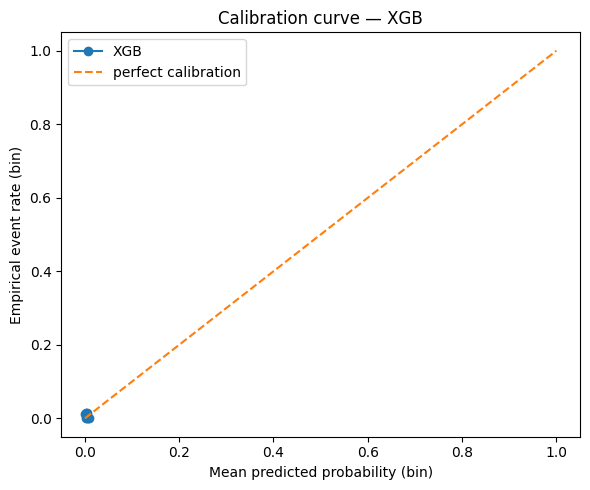

Saved: figures/calibration_XGB.png


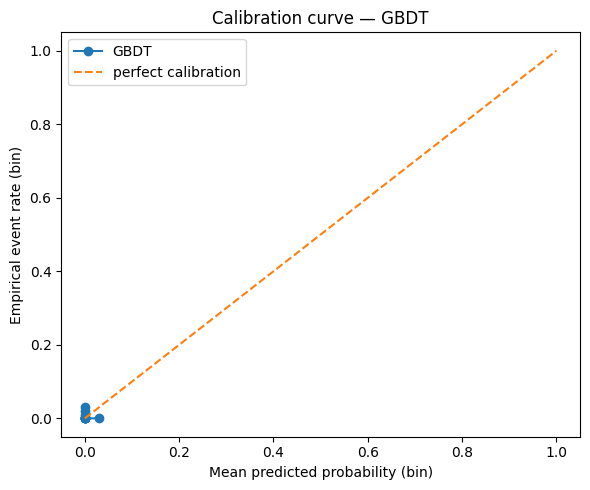

Saved: figures/calibration_GBDT.png


/tmp/ipython-input-1592507768.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = m.groupby("bin").agg(


,n,mean_p,event_rate
bin,,,
"(-0.001, 0.000992]",161,0.000388,0.012422
"(0.000992, 0.00198]",286,0.001984,0.000000
"(0.00198, 0.00298]",68,0.002976,0.014706
"(0.00298, 0.00397]",217,0.003968,0.013825
"(0.00397, 0.00595]",96,0.005446,0.000000
"(0.00595, 0.00794]",157,0.007665,0.000000
"(0.00794, 0.00893]",13,0.008929,0.000000


Saved: figures/calibration_table_xgb.csv


In [ ]:
# =========================
# Calibration / reliability plots for Y_ext prediction
# Requires: ml_res with ['Y_target','p_xgb','p_gbdt']
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

assert "ml_res" in globals(), "ml_res not found. Run ML cells first."
assert "Y_target" in ml_res.columns, "ml_res missing Y_target."
os.makedirs("figures", exist_ok=True)

def plot_calibration(y, p, name, n_bins=10):
    m = pd.DataFrame({"y": y, "p": p}).dropna()
    if m["y"].nunique() < 2:
        print(f"Skip {name}: y has <2 classes in available rows.")
        return

    frac_pos, mean_pred = calibration_curve(m["y"].astype(int), m["p"].astype(float), n_bins=n_bins, strategy="quantile")

    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
    plt.plot([0,1], [0,1], linestyle="--", label="perfect calibration")
    plt.xlabel("Mean predicted probability (bin)")
    plt.ylabel("Empirical event rate (bin)")
    plt.title(f"Calibration curve — {name}")
    plt.legend()
    plt.tight_layout()
    out = f"figures/calibration_{name}.png".replace(" ", "_")
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# XGB
if "p_xgb" in ml_res.columns:
    plot_calibration(ml_res["Y_target"], ml_res["p_xgb"], "XGB", n_bins=10)

# GBDT
if "p_gbdt" in ml_res.columns:
    plot_calibration(ml_res["Y_target"], ml_res["p_gbdt"], "GBDT", n_bins=10)

# Optional: bin table (quantile bins) for appendix
def calibration_table(y, p, q=10):
    m = pd.DataFrame({"y": y, "p": p}).dropna()
    m["bin"] = pd.qcut(m["p"], q=q, duplicates="drop")
    tab = m.groupby("bin").agg(
        n=("y","size"),
        mean_p=("p","mean"),
        event_rate=("y","mean")
    )
    return tab

if "p_xgb" in ml_res.columns:
    tab_x = calibration_table(ml_res["Y_target"], ml_res["p_xgb"], q=10)
    display(tab_x)
    tab_x.to_csv("figures/calibration_table_xgb.csv")
    print("Saved: figures/calibration_table_xgb.csv")

In [ ]:
# Align weekly roll vs weekly ML by week bucket (W-FRI)

import numpy as np
import pandas as pd
from IPython.display import display

# ---- 0) ensure datetime index ----
roll2 = roll.copy()
ml2   = ml_res.copy()

roll2.index = pd.to_datetime(roll2.index)
ml2.index   = pd.to_datetime(ml2.index)

roll2 = roll2.sort_index()
ml2   = ml2.sort_index()


# ---- 1) build common weekly key (W-FRI) ----
roll2["week"] = roll2.index.to_period("W-FRI").astype(str)
ml2["week"]   = ml2.index.to_period("W-FRI").astype(str)

# ---- 2) collapse to one row per week ----
roll_w = (roll2.groupby("week", as_index=False)
          .tail(1)
          .set_index("week"))

ml_w = (ml2.groupby("week", as_index=False)
        .tail(1)
        .set_index("week"))

# ---- 3) pick target column from ml_w ----
# priority: MS-tail main next > baseline main next > MS generic next > baseline next > Y_target
candidates = [
    "Y_ext_ms_main_next",
    "Y_ext_main_next",
    "Y_ext_ms_next",
    "Y_ext_next",
    "Y_target",
]
Y_COL = next((c for c in candidates if c in ml_w.columns), None)


need_roll = ["err_ratio", "vix_regime", "ms_state", "ms_p2"]
need_ml   = ["p_xgb", "p_gbdt", Y_COL]

missing_roll = [c for c in need_roll if c not in roll_w.columns]
missing_ml   = [c for c in need_ml if c not in ml_w.columns]

combo = (roll_w[need_roll]
         .join(ml_w[need_ml], how="inner")
         .dropna())

print("combo shape:", combo.shape)
print(f"Target used in combo: {Y_COL}")
print("event rate:", float(combo[Y_COL].astype(float).mean()) if len(combo) > 0 else np.nan)

# ---- 4) summary ----
def combo_desc(g: pd.DataFrame) -> pd.Series:
    er = g["err_ratio"].astype(float).to_numpy()
    px = g["p_xgb"].astype(float).to_numpy()
    pg = g["p_gbdt"].astype(float).to_numpy()
    y  = g[Y_COL].astype(int).to_numpy()

    def _corr(a, b):
        if len(a) < 10:
            return np.nan
        if np.std(a) == 0 or np.std(b) == 0:
            return np.nan
        return float(np.corrcoef(a, b)[0, 1])

    return pd.Series({
        "n": len(g),
        "P(err_ratio>2)": float((er > 2).mean()),
        "median_err_ratio": float(np.median(er)),
        "event_rate": float(y.mean()),
        "mean_p_xgb": float(px.mean()),
        "mean_p_gbdt": float(pg.mean()),
        "corr(err_ratio, p_xgb)": _corr(er, px),
        "corr(err_ratio, p_gbdt)": _corr(er, pg),
    })

if len(combo) == 0:
    print("\n⚠️ combo is empty. roll and ml_res do not overlap even at weekly bucket level.")
    print("roll weeks head:", list(roll_w.index[:5]))
    print("ml weeks head:", list(ml_w.index[:5]))
else:
    print("\n=== Forecast instability + ML probability by VIX regime ===")
    out = combo.groupby("vix_regime")[["err_ratio", "p_xgb", "p_gbdt", Y_COL]].apply(combo_desc)
    display(out.sort_index())

print("\n=== Weekly combo: by ms_state ===")
display(combo.groupby("ms_state")[["err_ratio", "p_xgb", "p_gbdt", Y_COL]].describe())

combo shape: (998, 7)
Target used in combo: Y_target
event rate: 0.006012024048096192

=== Forecast instability + ML probability by VIX regime ===


,n,P(err_ratio>2),median_err_ratio,event_rate,mean_p_xgb,mean_p_gbdt,"corr(err_ratio, p_xgb)","corr(err_ratio, p_gbdt)"
vix_regime,,,,,,,,
high,233.0,0.085837,0.700345,0.017167,0.003015,0.000019,0.041266,0.102151
low,533.0,0.022514,0.517933,0.000000,0.003436,0.005647,0.079304,0.043812
mid,232.0,0.047414,0.584754,0.008621,0.004319,0.000124,0.003302,0.173609



=== Weekly combo: by ms_state ===


err_ratio                                                                       p_xgb                                                         \
             count      mean       std       min       25%      50%       75%       max  count      mean       std  min       25%       50%       75%   
ms_state                                                                                                                                                
0            755.0  0.612685  0.509841  0.000000  0.211068  0.46581  0.927504  2.546537  755.0  0.003476  0.002456  0.0  0.001984  0.002976  0.004960   
1            243.0  1.161523  0.903286  0.002173  0.462669  1.00554  1.612255  4.972473  243.0  0.003752  0.002301  0.0  0.001984  0.003968  0.005952   

                   p_gbdt                                                                         Y_target                                               
               max  count      mean       std  min           25%           50%           75%  max    count      mean       std  min  25%  50%  75%  max  
ms_state                                                                                                                                                 
0         0.008929  755.0  0.002688  0.051433  0.0  6.083803e-10  2.803187e-09  7.431256e-07  1.0    755.0  0.003974  0.062952  0.0  0.0  0.0  0.0  1.0  
1         0.008929  243.0  0.004172  0.064150  0.0  6.084686e-10  4.664327e-08  1.825752e-06  1.0    243.0  0.012346  0.110651  0.0  0.0  0.0  0.0  1.0